# Models at an 80% adherence threshold (SMOTE-balanced)

Re-runs every model from `allYearMergeClean.ipynb` with the label redefined as
`is_adherent = meps_adherence_ratio >= 80` instead of `>= 60`. Nothing else about the
recipes changes, so numbers here are directly comparable to the 60% run.

**Why the resampling matters.** At 60% the two classes are almost even (51% / 49%), so an
unweighted fit is fine. At 80% they are not: non-adherent becomes the clear majority, and a
plain fit drifts toward predicting "non-adherent" for everybody — high accuracy, useless
recall on the adherent class. Section 1 quantifies exactly how lopsided it gets before any
model is trained. From Section 2 onward every fit runs inside an `imblearn` pipeline that
resamples **training folds only**; validation and holdout data are never touched.

Models ported over:

| Section | Model | Source cell in `allYearMergeClean.ipynb` |
| --- | --- | --- |
| 4 | Random Forest, F1-tuned and AUC-tuned (`HalvingGridSearchCV`) | Step M |
| 5 | XGBoost, F1-tuned and AUC-tuned (`HalvingGridSearchCV`) | Step N |
| 6 | Resampling ablation (new — none / class weight / SMOTE / SMOTE+undersample) | — |
| 7 | Prior-year lag ablation | Step P |
| 8 | Fixed-XGBoost feature-group comparison | Step Q |
| 9 | Paper-enriched XGBoost | Step R |

Caches live in `output/all_years/tables/model_cache_80pct/`, kept separate so the existing
60% caches in `model_cache/` are never overwritten.


In [1]:
from __future__ import annotations

import sys
import time
import warnings
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebooks/MEPS/new_models.ipynb -> walk up to the repo root that holds app/
_here = Path.cwd().resolve()
REPO = next(
    (p for p in (_here, *_here.parents) if (p / "app" / "clean_meps.py").exists()),
    None,
)
if REPO is None:
    raise FileNotFoundError("could not find app/clean_meps.py at or above the CWD")
sys.path.insert(0, str(REPO / "app"))

from clean_meps import all_years_output_dirs  # noqa: E402

ADH_THRESHOLD = 80  # this notebook
BASELINE_THRESHOLD = 60  # what allYearMergeClean.ipynb used
YEARS = [2020, 2021, 2022, 2023]
RANDOM_STATE = 42

TABLES_ALL, GRAPHS_ALL = all_years_output_dirs()
PANEL_PATH = TABLES_ALL / "model_df_all_years.parquet"

pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=FutureWarning)

panel = pd.read_parquet(PANEL_PATH)
n_cols_in = panel.shape[1]

# The parquet ships is_adherent at >=60. Relabel in place at >=80; keep the old label as a
# standalone Series so it can never leak into a feature matrix and change the column counts.
adherence_ratio = panel["meps_adherence_ratio"]
label_60 = (adherence_ratio >= BASELINE_THRESHOLD).astype(int)
panel["is_adherent"] = (adherence_ratio >= ADH_THRESHOLD).astype(int)
assert panel.shape[1] == n_cols_in, "relabelling must not add or drop columns"

model_df_all = panel

print(f"REPO:  {REPO}")
print(f"panel: {PANEL_PATH}")
print(
    f"{len(model_df_all):,} person-years | {model_df_all['DUPERSID'].nunique():,} people | "
    f"{model_df_all.shape[1]} columns"
)
print(f"rows by YEAR: {model_df_all['YEAR'].value_counts().sort_index().to_dict()}")
print(
    f"\nlabel at >={ADH_THRESHOLD}%: adherent rate {model_df_all['is_adherent'].mean():.4f}"
    f"  (was {label_60.mean():.4f} at >={BASELINE_THRESHOLD}%)"
)


REPO:  /Users/friana/Medical Adherence
panel: /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_df_all_years.parquet
28,691 person-years | 18,673 people | 328 columns
rows by YEAR: {2020: 7718, 2021: 8377, 2022: 6770, 2023: 5826}

label at >=80%: adherent rate 0.2728  (was 0.5140 at >=60%)


## 1. How many people are non-adherent at 80%?

This is the question that decides the resampling strategy, so it runs before any model. Three
views: a threshold sweep to show where the balance flips, the headline counts at 80%, and the
same counts per survey year and per distinct person.


In [2]:
# Threshold sweep: how the class split moves as the cutoff rises.
sweep = []
for th in [50, 55, 60, 65, 70, 75, 80, 85, 90, 95]:
    lab = (adherence_ratio >= th).astype(int)
    n_adh = int(lab.sum())
    n_non = int(len(lab) - n_adh)
    minority = min(n_adh, n_non)
    sweep.append({
        "threshold": th,
        "adherent": n_adh,
        "non_adherent": n_non,
        "% non_adherent": 100 * n_non / len(lab),
        "minority class": "adherent" if n_adh < n_non else "non-adherent",
        "imbalance ratio": max(n_adh, n_non) / minority if minority else np.nan,
    })

sweep_df = pd.DataFrame(sweep)
print(f"Person-years: {len(adherence_ratio):,}")
display(
    sweep_df.style.format({"% non_adherent": "{:.1f}", "imbalance ratio": "{:.2f}"})
    .hide(axis="index")
)

n_non_80 = int((adherence_ratio < ADH_THRESHOLD).sum())
n_adh_80 = int((adherence_ratio >= ADH_THRESHOLD).sum())
IMBALANCE_RATIO = n_non_80 / n_adh_80

print(
    f"\nAt >={ADH_THRESHOLD}%:\n"
    f"  NON-ADHERENT  {n_non_80:6,} person-years  ({100 * n_non_80 / len(adherence_ratio):.1f}%)  <- majority\n"
    f"  ADHERENT      {n_adh_80:6,} person-years  ({100 * n_adh_80 / len(adherence_ratio):.1f}%)  <- minority\n"
    f"  imbalance ratio {IMBALANCE_RATIO:.2f} : 1\n"
    f"\nFor contrast, at >={BASELINE_THRESHOLD}% the split was "
    f"{int((~label_60.astype(bool)).sum()):,} non-adherent / {int(label_60.sum()):,} adherent "
    f"({(~label_60.astype(bool)).sum() / max(label_60.sum(), 1):.2f} : 1)."
)
print(
    "\nSo the minority class flips: at 60% the model had to work to find non-adherent people,\n"
    f"at {ADH_THRESHOLD}% it is the adherent people who are scarce. Predicting 'non-adherent'\n"
    f"for every row would already score {100 * n_non_80 / len(adherence_ratio):.1f}% accuracy."
)


Person-years: 28,691


threshold,adherent,non_adherent,% non_adherent,minority class,imbalance ratio
50,17435,11256,39.2,non-adherent,1.55
55,16275,12416,43.3,non-adherent,1.31
60,14747,13944,48.6,non-adherent,1.06
65,13374,15317,53.4,adherent,1.15
70,11687,17004,59.3,adherent,1.45
75,8824,19867,69.2,adherent,2.25
80,7826,20865,72.7,adherent,2.67
85,6450,22241,77.5,adherent,3.45
90,5472,23219,80.9,adherent,4.24
95,4460,24231,84.5,adherent,5.43



At >=80%:
  NON-ADHERENT  20,865 person-years  (72.7%)  <- majority
  ADHERENT       7,826 person-years  (27.3%)  <- minority
  imbalance ratio 2.67 : 1

For contrast, at >=60% the split was 13,944 non-adherent / 14,747 adherent (0.95 : 1).

So the minority class flips: at 60% the model had to work to find non-adherent people,
at 80% it is the adherent people who are scarce. Predicting 'non-adherent'
for every row would already score 72.7% accuracy.


Person-years by survey year (threshold >=80%):


,person_years,adherent,non_adherent,% non_adherent
YEAR,,,,
2020,7718,2276,5442,70.5
2021,8377,2227,6150,73.4
2022,6770,1844,4926,72.8
2023,5826,1479,4347,74.6



Distinct people: 18,673
  non-adherent in every year they appear : 12,128  (64.9%)
  adherent in every year they appear     :  3,359  (18.0%)
  mixed across years                     :  3,186  (17.1%)

  appear as non-adherent at least once   : 15,314
  appear as adherent at least once       :  6,545


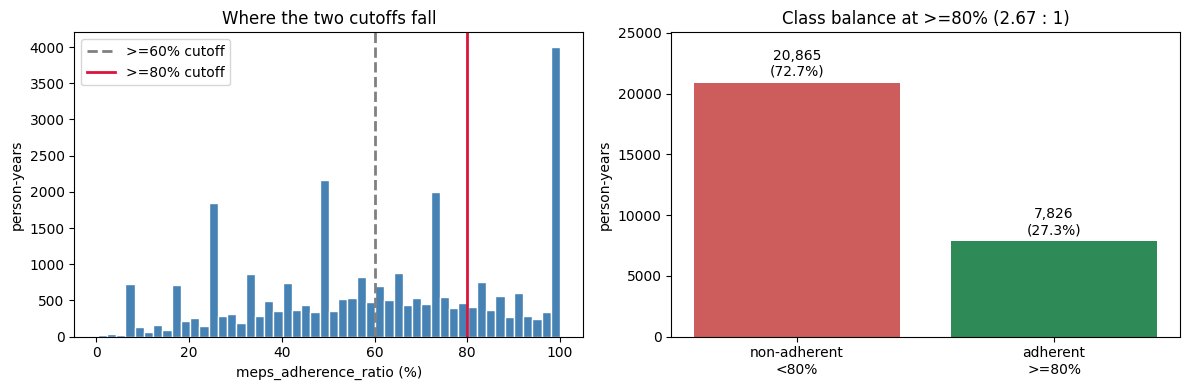

In [3]:
# Same counts split by survey year and by distinct person.
by_year = (
    model_df_all.assign(non_adherent=1 - model_df_all["is_adherent"])
    .groupby("YEAR")
    .agg(
        person_years=("is_adherent", "size"),
        adherent=("is_adherent", "sum"),
        non_adherent=("non_adherent", "sum"),
    )
)
by_year["% non_adherent"] = 100 * by_year["non_adherent"] / by_year["person_years"]
print(f"Person-years by survey year (threshold >={ADH_THRESHOLD}%):")
display(by_year.style.format({"% non_adherent": "{:.1f}"}))

# A person appears in up to 4 years, so these person-level buckets overlap by design.
per_person = model_df_all.groupby("DUPERSID")["is_adherent"].agg(["size", "sum"])
n_people = len(per_person)
never = int((per_person["sum"] == 0).sum())
always = int((per_person["sum"] == per_person["size"]).sum())
mixed = n_people - never - always

print(f"\nDistinct people: {n_people:,}")
print(f"  non-adherent in every year they appear : {never:6,}  ({100 * never / n_people:.1f}%)")
print(f"  adherent in every year they appear     : {always:6,}  ({100 * always / n_people:.1f}%)")
print(f"  mixed across years                     : {mixed:6,}  ({100 * mixed / n_people:.1f}%)")
print(
    f"\n  appear as non-adherent at least once   : "
    f"{int((per_person['sum'] < per_person['size']).sum()):6,}"
)
print(
    f"  appear as adherent at least once       : "
    f"{int((per_person['sum'] > 0).sum()):6,}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(adherence_ratio, bins=50, color="steelblue", edgecolor="white")
for th, colour, style in [(BASELINE_THRESHOLD, "grey", "--"), (ADH_THRESHOLD, "crimson", "-")]:
    axes[0].axvline(th, color=colour, linestyle=style, linewidth=2, label=f">={th}% cutoff")
axes[0].set_xlabel("meps_adherence_ratio (%)")
axes[0].set_ylabel("person-years")
axes[0].set_title("Where the two cutoffs fall")
axes[0].legend()

bars = axes[1].bar(
    [f"non-adherent\n<{ADH_THRESHOLD}%", f"adherent\n>={ADH_THRESHOLD}%"],
    [n_non_80, n_adh_80],
    color=["indianred", "seagreen"],
)
axes[1].bar_label(
    bars,
    labels=[
        f"{n_non_80:,}\n({100 * n_non_80 / len(adherence_ratio):.1f}%)",
        f"{n_adh_80:,}\n({100 * n_adh_80 / len(adherence_ratio):.1f}%)",
    ],
    padding=3,
)
axes[1].set_ylabel("person-years")
axes[1].set_ylim(0, n_non_80 * 1.2)
axes[1].set_title(f"Class balance at >={ADH_THRESHOLD}% ({IMBALANCE_RATIO:.2f} : 1)")

plt.tight_layout()
plt.show()


## 2. Resampling strategy

One naming note up front: **SMOTE is an over-sampler**, not an under-sampler. It manufactures
new minority rows by interpolating between a minority row and its nearest minority neighbours.
The plan asked for here — use SMOTE, and lean on the fact that there is plenty of non-adherent
data to spare — is the original Chawla et al. recipe, which pairs the two:

1. `SMOTE(sampling_strategy=0.5)` raises the adherent minority to half the majority count.
2. `RandomUnderSampler(sampling_strategy=1.0)` drops random non-adherent rows to finish the balance.

Meeting in the middle means roughly a third of the balanced training set is synthetic, instead
of the ~50% that pure SMOTE-to-parity would produce. Set `RESAMPLE_MODE` to `"smote"`,
`"under"`, or `"none"` to change that; Section 6 fits all of them side by side.

Two guards on top of plain `SMOTE`, both in `AdaptiveSMOTE` below:

- **Tiny folds.** `HalvingGridSearchCV` starts on ~90 rows, which can leave fewer minority rows
  than the default 5 neighbours require, and stock SMOTE raises there. `k_neighbors` shrinks to fit.
- **Fractional dummies.** 310 of the 319 features are 0/1 indicators (`RXDRG_*`, `ICD_*`,
  demographics). Interpolating them produces values like 0.37 — a patient 37% on metformin.
  `SMOTENC` handles this correctly but takes ~37s per call versus 0.3s, far too slow inside a
  halving search, so synthetic rows are rounded back to 0/1 instead.

Everything is wired through `imblearn.pipeline.Pipeline`, so resampling happens **inside each
CV fold's training half only**. Validation folds and the holdout keep their true class balance,
which is what makes the reported metrics honest.


In [4]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

RESAMPLE_MODE = "smote_under"  # "smote_under" | "smote" | "under" | "none"
SMOTE_RATIO = 0.5  # minority raised to this fraction of the majority
UNDER_RATIO = 1.0  # majority cut to this fraction of the (new) minority
SMOTE_K_NEIGHBORS = 5
SMOTE_ROUND_BINARY = True


class AdaptiveSMOTE(SMOTE):
    """SMOTE hardened for this panel: survives tiny folds, keeps dummies at 0/1.

    Deviates from stock ``SMOTE`` in two ways. ``k_neighbors`` shrinks when a fold holds
    fewer minority rows than the default 5 neighbours need, and synthetic values are
    rounded on columns that arrived binary so the 310 indicator features stay indicators.
    Folds with a single minority row are passed through untouched.
    """

    def _fit_resample(self, X, y):
        counts = Counter(np.asarray(y).tolist())
        n_minority = min(counts.values())
        if n_minority < 2:
            return X, y

        self.k_neighbors = max(1, min(SMOTE_K_NEIGHBORS, n_minority - 1))
        X_res, y_res = super()._fit_resample(X, y)

        if SMOTE_ROUND_BINARY:
            X_arr = np.asarray(X)
            binary = ((X_arr == 0) | (X_arr == 1)).all(axis=0)
            if binary.any():
                X_res = np.asarray(X_res).copy()
                X_res[:, binary] = np.rint(X_res[:, binary])

        return X_res, y_res


def make_resample_steps(mode: str = None) -> list[tuple[str, object]]:
    """Pipeline steps that rebalance a training fold. Empty list means no resampling."""
    mode = mode or RESAMPLE_MODE
    if mode == "none":
        return []
    if mode == "smote":
        return [("smote", AdaptiveSMOTE(sampling_strategy=1.0, random_state=RANDOM_STATE))]
    if mode == "under":
        return [("under", RandomUnderSampler(sampling_strategy=1.0, random_state=RANDOM_STATE))]
    if mode == "smote_under":
        return [
            ("smote", AdaptiveSMOTE(sampling_strategy=SMOTE_RATIO, random_state=RANDOM_STATE)),
            ("under", RandomUnderSampler(sampling_strategy=UNDER_RATIO, random_state=RANDOM_STATE)),
        ]
    raise ValueError(f"unknown RESAMPLE_MODE: {mode!r}")


RESAMPLE_STEPS = make_resample_steps()
RESAMPLE_LABEL = {
    "none": "none",
    "smote": "SMOTE to parity",
    "under": "random undersample",
    "smote_under": f"SMOTE {SMOTE_RATIO} + undersample {UNDER_RATIO}",
}[RESAMPLE_MODE]


def make_pipeline(clf, mode: str = None) -> ImbPipeline:
    """Wrap an estimator so its training folds get resampled and nothing else does."""
    return ImbPipeline([*make_resample_steps(mode), ("clf", clf)])


def resample_now(X, y, mode: str = None):
    """Apply the resamplers eagerly, for fixed-parameter fits that skip the grid search."""
    steps = make_resample_steps(mode)
    X_res, y_res = X, y
    for _, sampler in steps:
        X_res, y_res = sampler.fit_resample(X_res, y_res)
    return X_res, y_res


def describe_balance(y, label: str) -> None:
    counts = Counter(np.asarray(y).astype(int).tolist())
    total = sum(counts.values())
    print(
        f"  {label:<28} n={total:6,}  "
        f"non-adherent={counts.get(0, 0):6,} ({100 * counts.get(0, 0) / total:4.1f}%)  "
        f"adherent={counts.get(1, 0):6,} ({100 * counts.get(1, 0) / total:4.1f}%)"
    )


print(f"RESAMPLE_MODE = {RESAMPLE_MODE!r}  ->  {RESAMPLE_LABEL}")
print(f"steps: {[name for name, _ in RESAMPLE_STEPS] or ['(none)']}")


RESAMPLE_MODE = 'smote_under'  ->  SMOTE 0.5 + undersample 1.0
steps: ['smote', 'under']


In [5]:
# Shared plumbing: model cache (separate from the 60% run) and a scoring helper.
from sklearn.metrics import (
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

# Set True once to retrain everything and refresh the caches.
FORCE_REFIT_MODELS = False

MODELS_CACHE_DIR = TABLES_ALL / "model_cache_80pct"
MODELS_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CLASS_LABELS = (f"not adherent (<{ADH_THRESHOLD}%)", f"adherent (>={ADH_THRESHOLD}%)")


def model_metrics_path(name: str) -> Path:
    return MODELS_CACHE_DIR / f"{name}_metrics.parquet"


def model_est_path(name: str) -> Path:
    return MODELS_CACHE_DIR / f"{name}.joblib"


def try_load_model_cache(name: str):
    """Return dict(metrics, estimator) on a cache hit, else None."""
    mp = model_metrics_path(name)
    if FORCE_REFIT_MODELS or not mp.exists():
        return None
    metrics = pd.read_parquet(mp)
    est = None
    ep = model_est_path(name)
    if ep.exists():
        est = joblib.load(ep)
    print(f"[model cache hit] {name} - skip training ({mp.name})")
    return {"metrics": metrics, "estimator": est}


def save_model_cache(name: str, metrics_df: pd.DataFrame, estimator=None) -> None:
    MODELS_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    mp = model_metrics_path(name)
    metrics_df.to_parquet(mp, index=False)
    print(f"[model cache write] {mp}")
    if estimator is not None:
        joblib.dump(estimator, model_est_path(name))
        print(f"[model cache write] {model_est_path(name)}")


def plot_cm_with_recall(cm, ax, title, labels=CLASS_LABELS, cmap="Blues"):
    """2x2 confusion matrix with row-normalised recall plus accuracy in the title."""
    cm = np.asarray(cm)
    row_totals = cm.sum(axis=1, keepdims=True)
    pct = np.divide(
        cm * 100.0, row_totals, out=np.zeros_like(cm, dtype=float), where=row_totals > 0
    )
    acc = cm.trace() / cm.sum() * 100 if cm.sum() > 0 else 0.0

    ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8, rotation=90, va="center")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title}\n(accuracy: {acc:.1f}%)", fontsize=10)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{int(cm[i, j])}\n({pct[i, j]:.1f}%)",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=11,
            )
    return ax


SUMMARY_ROWS: list[dict] = []


def record(
    name, y_true, y_proba=None, *, y_pred=None, n_features=None,
    resampling=None, note="", verbose=True,
):
    """Score a holdout, print the usual report, and log one row for the final summary.

    Recall on the adherent class is the number to watch: it is the one an imbalanced fit
    quietly gives up in exchange for accuracy on the non-adherent majority.
    """
    y_true = np.asarray(y_true).astype(int)
    if y_pred is None:
        if y_proba is None:
            raise ValueError("pass y_proba or y_pred")
        y_pred = (np.asarray(y_proba) >= 0.5).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    row = {
        "model": name,
        "threshold": ADH_THRESHOLD,
        "resampling": RESAMPLE_LABEL if resampling is None else resampling,
        "n_features": n_features,
        "n_test": int(len(y_true)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)) if y_proba is not None else np.nan,
        "pr_auc": float(average_precision_score(y_true, y_proba)) if y_proba is not None else np.nan,
        "accuracy": float((y_pred == y_true).mean()),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "recall_non_adherent": float(rec[0]),
        "recall_adherent": float(rec[1]),
        "precision_adherent": float(prec[1]),
        "f1_adherent": float(f1[1]),
        "note": note,
    }

    for i, existing in enumerate(SUMMARY_ROWS):
        if existing["model"] == name:
            SUMMARY_ROWS[i] = row
            break
    else:
        SUMMARY_ROWS.append(row)

    if verbose:
        print(f"\n--- {name} ---")
        print(classification_report(y_true, y_pred, digits=3, target_names=CLASS_LABELS))
        print(
            f"accuracy {row['accuracy']:.3f} | balanced acc {row['balanced_accuracy']:.3f} | "
            f"ROC-AUC {row['roc_auc']:.4f} | PR-AUC {row['pr_auc']:.4f}"
        )
        print(
            f"recall: non-adherent {row['recall_non_adherent']:.3f} | "
            f"adherent {row['recall_adherent']:.3f}"
        )
    return row


print(f"helpers ready | cache dir: {MODELS_CACHE_DIR}")
print(f"FORCE_REFIT_MODELS={FORCE_REFIT_MODELS}")


helpers ready | cache dir: /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_cache_80pct
FORCE_REFIT_MODELS=False


## 3. Training frame and person-level split

Same recipe as Step L/M of `allYearMergeClean.ipynb`: drop `DUPERSID`, `YEAR` and
`meps_adherence_ratio` (the label's own source) from the features, then hold out 20% of
**people** rather than 20% of rows, so no patient contributes to both sides via a different
survey year. The RNG seed matches the 60% run, so the split is identical and only the label differs.


In [6]:
TEST_FRAC = 0.2

training_df = model_df_all.drop(
    columns=["DUPERSID", "YEAR", "meps_adherence_ratio"], errors="ignore"
).copy()
print(f"model_df_all: {model_df_all.shape[0]:,} rows x {model_df_all.shape[1]} cols")
print(f"training_df:  {training_df.shape[0]:,} rows x {training_df.shape[1]} cols")

# Person-level holdout, same seed and draw as the 60% notebook.
unique_ids = model_df_all["DUPERSID"].drop_duplicates().to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
n_test = int(round(TEST_FRAC * len(unique_ids)))
test_ids = set(rng.choice(unique_ids, size=n_test, replace=False).tolist())

train = model_df_all[~model_df_all["DUPERSID"].isin(test_ids)].copy()
test = model_df_all[model_df_all["DUPERSID"].isin(test_ids)].copy()

overlap = len(set(train["DUPERSID"]) & set(test["DUPERSID"]))
print(
    f"\nperson split: {len(unique_ids):,} people | test_ids={len(test_ids):,} "
    f"({TEST_FRAC:.0%}) | train rows={len(train):,} | test rows={len(test):,}"
)
print(f"DUPERSID overlap train & test = {overlap}")
assert overlap == 0, f"person leakage: overlap={overlap}"
print("person-leakage check OK (overlap == 0)")

DROP_FROM_X = ["DUPERSID", "YEAR", "is_adherent", "meps_adherence_ratio", "n_drugs", "n_conditions"]
TEXT_COLS = ["medication_dose_unit", "medication_qty_unit", "medication_freq_bin"]


def _rf_X(df: pd.DataFrame) -> pd.DataFrame:
    X = df.drop(columns=[c for c in DROP_FROM_X + TEXT_COLS if c in df.columns]).copy()
    if "AGE" in X.columns:
        X["AGE"] = pd.to_numeric(X["AGE"], errors="coerce")
    non_num = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    if non_num:
        raise TypeError(f"non-numeric columns still in X: {non_num}")
    return X.astype(np.float64)


X_train = _rf_X(train)
X_test = _rf_X(test).reindex(columns=X_train.columns)
med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med)
X_test = X_test.fillna(med)

y_train = train["is_adherent"].astype(int)
y_test = test["is_adherent"].astype(int)

print(f"\nX shape: train {X_train.shape} | test {X_test.shape}")
print("class balance:")
describe_balance(y_train, "train (raw)")
describe_balance(y_test, "test (raw, never resampled)")


model_df_all: 28,691 rows x 328 cols
training_df:  28,691 rows x 325 cols

person split: 18,673 people | test_ids=3,735 (20%) | train rows=22,960 | test rows=5,731
DUPERSID overlap train & test = 0
person-leakage check OK (overlap == 0)

X shape: train (22960, 319) | test (5731, 319)
class balance:
  train (raw)                  n=22,960  non-adherent=16,728 (72.9%)  adherent= 6,232 (27.1%)
  test (raw, never resampled)  n= 5,731  non-adherent= 4,137 (72.2%)  adherent= 1,594 (27.8%)


In [7]:
# What the resamplers actually do to the training matrix, in counts.
print(f"RESAMPLE_MODE={RESAMPLE_MODE!r} -> {RESAMPLE_LABEL}\n")
describe_balance(y_train, "before")

X_prev, y_prev = X_train, y_train
for step_name, sampler in RESAMPLE_STEPS:
    X_prev, y_prev = sampler.fit_resample(X_prev, y_prev)
    describe_balance(y_prev, f"after {step_name}")

if RESAMPLE_STEPS:
    n_real_minority = int((y_train == 1).sum())
    n_final_minority = int(np.asarray(y_prev).sum())
    n_synth = max(0, n_final_minority - n_real_minority)
    n_dropped = int((y_train == 0).sum()) - int((np.asarray(y_prev) == 0).sum())
    print(
        f"\n  synthetic adherent rows created : {n_synth:,}"
        f"  ({100 * n_synth / max(len(y_prev), 1):.1f}% of the balanced set)"
    )
    print(f"  real non-adherent rows dropped  : {n_dropped:,}")
    print(f"  training rows {len(y_train):,} -> {len(y_prev):,}")

    binary_cols = [c for c in X_train.columns if set(pd.unique(X_train[c].to_numpy())) <= {0.0, 1.0}]
    frac_cells = int(((np.asarray(X_prev)[:, [X_train.columns.get_loc(c) for c in binary_cols]] % 1) != 0).sum())
    print(
        f"\n  {len(binary_cols)} of {X_train.shape[1]} features are 0/1 dummies; "
        f"fractional cells left in them after rounding: {frac_cells}"
    )


RESAMPLE_MODE='smote_under' -> SMOTE 0.5 + undersample 1.0

  before                       n=22,960  non-adherent=16,728 (72.9%)  adherent= 6,232 (27.1%)
  after smote                  n=25,092  non-adherent=16,728 (66.7%)  adherent= 8,364 (33.3%)
  after under                  n=16,728  non-adherent= 8,364 (50.0%)  adherent= 8,364 (50.0%)

  synthetic adherent rows created : 2,132  (12.7% of the balanced set)
  real non-adherent rows dropped  : 8,364
  training rows 22,960 -> 16,728

  310 of 319 features are 0/1 dummies; fractional cells left in them after rounding: 0


## 4. Random Forest (Step M at 80%)

Same `PARAM_GRID`, `HalvingGridSearchCV` settings (`factor=3`, `resource="n_samples"`,
5-fold stratified CV) and cache pattern as the 60% run. Two changes:

- The estimator is now a pipeline, so each candidate is scored on validation folds that keep
  their real class balance while its training half is resampled.
- `class_weight` is pinned to `None` while resampling is active. Rebalancing the fold *and*
  reweighting the loss corrects the same imbalance twice and pushes the model past the target.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingGridSearchCV, StratifiedKFold, train_test_split

PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}
if RESAMPLE_STEPS:
    # SMOTE already rebalances the fold; leave the loss weights alone.
    PARAM_GRID["class_weight"] = [None]

CV_FOLDS = 5
PIPE_GRID = {f"clf__{k}": v for k, v in PARAM_GRID.items()}

print(f"grid combos: {np.prod([len(v) for v in PARAM_GRID.values()])} x {CV_FOLDS} folds")
print(f"class_weight options: {PARAM_GRID['class_weight']}")
print(f"pipeline steps: {[name for name, _ in RESAMPLE_STEPS] + ['clf']}")


grid combos: 216 x 5 folds
class_weight options: [None]
pipeline steps: ['smote', 'under', 'clf']


[model cache hit] rf_f1_halving_80pct - skip training (rf_f1_halving_80pct_metrics.parquet)


,model,scoring,resampling,best_cv_score,test_accuracy,test_roc_auc,test_recall_adherent,param_clf__class_weight,param_clf__max_depth,param_clf__max_features,param_clf__min_samples_leaf,param_clf__min_samples_split,param_clf__n_estimators
0,rf_f1_halving_80pct,f1,SMOTE 0.5 + undersample 1.0,0.417122,0.530099,0.572304,0.572773,None,10,log2,2,10,100



--- RF (F1-tuned) ---
                     precision    recall  f1-score   support

not adherent (<80%)      0.757     0.514     0.612      4137
   adherent (>=80%)      0.312     0.573     0.404      1594

           accuracy                          0.530      5731
          macro avg      0.535     0.543     0.508      5731
       weighted avg      0.633     0.530     0.554      5731

accuracy 0.530 | balanced acc 0.543 | ROC-AUC 0.5723 | PR-AUC 0.3264
recall: non-adherent 0.514 | adherent 0.573


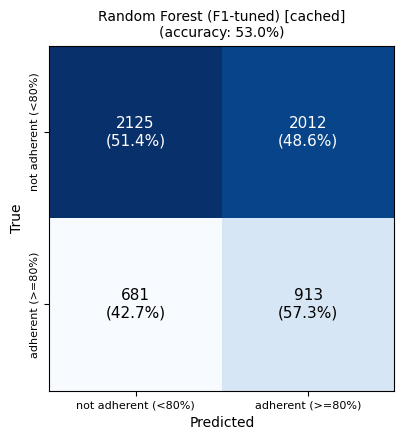

In [9]:
# HalvingGridSearchCV - F1-tuned Random Forest (F1 is on the adherent minority class)
_CACHE_NAME = "rf_f1_halving_80pct"
_cached = try_load_model_cache(_CACHE_NAME)

if _cached is not None:
    display(_cached["metrics"])
    best_rf = _cached["estimator"]
    if best_rf is None:
        print("WARN: metrics cached but estimator .joblib missing - set FORCE_REFIT_MODELS=True once.")
    else:
        y_pred = best_rf.predict(X_test)
        y_proba = best_rf.predict_proba(X_test)[:, 1]
        record(
            "RF (F1-tuned)", y_test, y_proba, y_pred=y_pred,
            n_features=X_train.shape[1], note="Step M, cached",
        )
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        plot_cm_with_recall(confusion_matrix(y_test, y_pred), ax, "Random Forest (F1-tuned) [cached]")
        plt.tight_layout()
        plt.show()
        best_score = float(_cached["metrics"]["best_cv_score"].iloc[0])
else:
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search = HalvingGridSearchCV(
        estimator=make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
        param_grid=PIPE_GRID,
        scoring="f1",
        cv=cv,
        factor=3,
        resource="n_samples",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
    print("Best params:", search.best_params_)
    print(f"Best CV f1 (adherent class): {search.best_score_:.4f}")
    print(
        f"Iterations: {search.n_iterations_} | candidates per iter: {search.n_candidates_} | "
        f"resources per iter: {search.n_resources_}"
    )

    best_rf = search.best_estimator_
    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:, 1]
    row = record(
        "RF (F1-tuned)", y_test, y_proba, y_pred=y_pred,
        n_features=X_train.shape[1], note="Step M",
    )

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    plot_cm_with_recall(confusion_matrix(y_test, y_pred), ax, "Random Forest (F1-tuned)")
    plt.tight_layout()
    plt.show()

    best_score = float(search.best_score_)
    save_model_cache(
        _CACHE_NAME,
        pd.DataFrame([{
            "model": _CACHE_NAME,
            "scoring": "f1",
            "resampling": RESAMPLE_LABEL,
            "best_cv_score": best_score,
            "test_accuracy": row["accuracy"],
            "test_roc_auc": row["roc_auc"],
            "test_recall_adherent": row["recall_adherent"],
            **{f"param_{k}": str(v) for k, v in search.best_params_.items()},
        }]),
        best_rf,
    )


[model cache hit] rf_auc_halving_80pct - skip training (rf_auc_halving_80pct_metrics.parquet)


,model,scoring,resampling,best_cv_score,test_roc_auc,test_recall_adherent,param_clf__class_weight,param_clf__max_depth,param_clf__max_features,param_clf__min_samples_leaf,param_clf__min_samples_split,param_clf__n_estimators
0,rf_auc_halving_80pct,roc_auc,SMOTE 0.5 + undersample 1.0,0.600687,0.57993,0.529486,None,20,log2,1,2,300



--- RF (AUC-tuned) ---
                     precision    recall  f1-score   support

not adherent (<80%)      0.760     0.575     0.655      4137
   adherent (>=80%)      0.324     0.529     0.402      1594

           accuracy                          0.562      5731
          macro avg      0.542     0.552     0.528      5731
       weighted avg      0.639     0.562     0.584      5731

accuracy 0.562 | balanced acc 0.552 | ROC-AUC 0.5799 | PR-AUC 0.3329
recall: non-adherent 0.575 | adherent 0.529


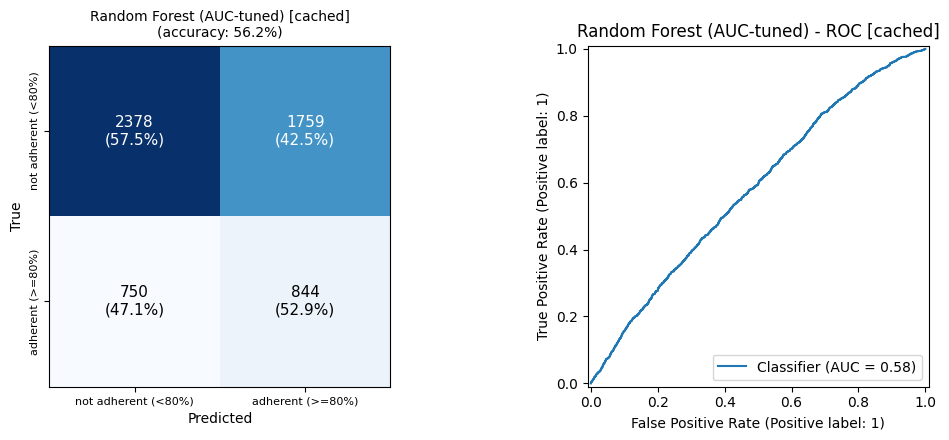

In [10]:
# HalvingGridSearchCV - AUC-tuned Random Forest
_CACHE_NAME = "rf_auc_halving_80pct"
_cached = try_load_model_cache(_CACHE_NAME)


def _rf_auc_report(model, tag=""):
    y_pred_auc = model.predict(X_test)
    y_proba_auc = model.predict_proba(X_test)[:, 1]
    row = record(
        "RF (AUC-tuned)", y_test, y_proba_auc, y_pred=y_pred_auc,
        n_features=X_train.shape[1], note=f"Step M{tag}",
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    plot_cm_with_recall(
        confusion_matrix(y_test, y_pred_auc), axes[0], f"Random Forest (AUC-tuned){tag}"
    )
    RocCurveDisplay.from_predictions(y_test, y_proba_auc, ax=axes[1])
    axes[1].set_title(f"Random Forest (AUC-tuned) - ROC{tag}")
    plt.tight_layout()
    plt.show()
    return row, y_proba_auc


if _cached is not None:
    display(_cached["metrics"])
    best_rf_auc = _cached["estimator"]
    if best_rf_auc is None:
        print("WARN: metrics cached but estimator .joblib missing - set FORCE_REFIT_MODELS=True once.")
    else:
        _, y_proba_rf_auc = _rf_auc_report(best_rf_auc, " [cached]")
        best_score_auc = float(_cached["metrics"]["best_cv_score"].iloc[0])
else:
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search_auc = HalvingGridSearchCV(
        estimator=make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
        param_grid=PIPE_GRID,
        scoring="roc_auc",
        cv=cv,
        factor=3,
        resource="n_samples",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    t0 = time.perf_counter()
    search_auc.fit(X_train, y_train)
    print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
    print("Best params:", search_auc.best_params_)
    print(f"Best CV roc_auc: {search_auc.best_score_:.4f}")
    print(
        f"Iterations: {search_auc.n_iterations_} | candidates per iter: {search_auc.n_candidates_} | "
        f"resources per iter: {search_auc.n_resources_}"
    )

    best_rf_auc = search_auc.best_estimator_
    row_auc, y_proba_rf_auc = _rf_auc_report(best_rf_auc)
    best_score_auc = float(search_auc.best_score_)
    save_model_cache(
        _CACHE_NAME,
        pd.DataFrame([{
            "model": _CACHE_NAME,
            "scoring": "roc_auc",
            "resampling": RESAMPLE_LABEL,
            "best_cv_score": best_score_auc,
            "test_roc_auc": row_auc["roc_auc"],
            "test_recall_adherent": row_auc["recall_adherent"],
            **{f"param_{k}": str(v) for k, v in search_auc.best_params_.items()},
        }]),
        best_rf_auc,
    )


Gini importance - top 20 (AUC-tuned RF, SMOTE 0.5 + undersample 1.0)


,gini_importance
AGE,0.053630
REGIONXX,0.052820
FAMINC,0.047322
PATIENT_COST_SHARE,0.046958
medication_dose,0.046882
medication_freq,0.045634
RACETHX,0.044312
EDUCYR,0.041936
MARRYXX,0.035994
ICD_J45,0.011116


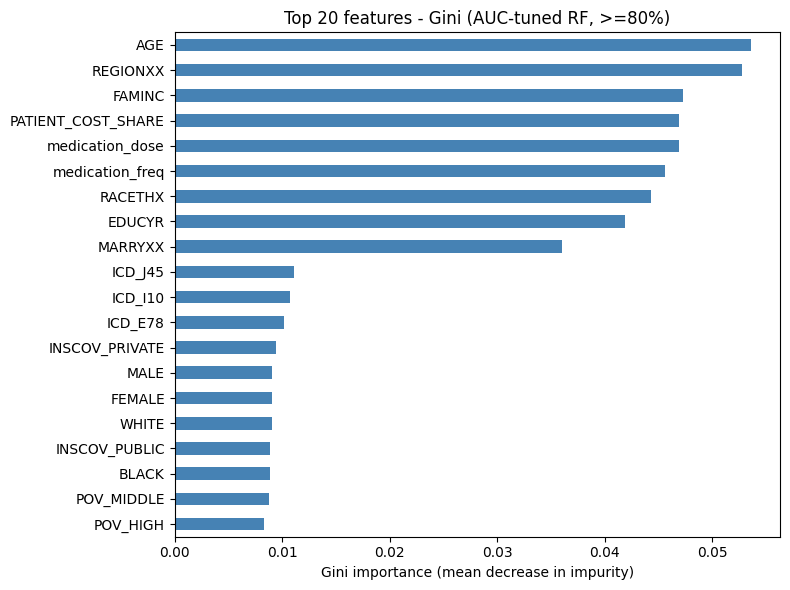

In [11]:
# Gini feature importance - prefers the AUC-tuned forest
_rf_pipe = best_rf_auc if "best_rf_auc" in dir() and best_rf_auc is not None else best_rf
_rf_label = "AUC-tuned" if _rf_pipe is locals().get("best_rf_auc") else "F1-tuned"

if _rf_pipe is None:
    print("Skip Gini importance - cached metrics only. Set FORCE_REFIT_MODELS=True to retrain.")
else:
    TOP_N = 20
    _forest = _rf_pipe.named_steps["clf"]
    gini_imp = (
        pd.Series(_forest.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
    )
    print(f"Gini importance - top {TOP_N} ({_rf_label} RF, {RESAMPLE_LABEL})")
    display(gini_imp.head(TOP_N).to_frame("gini_importance"))

    fig, ax = plt.subplots(figsize=(8, 6))
    gini_imp.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Gini importance (mean decrease in impurity)")
    ax.set_title(f"Top {TOP_N} features - Gini ({_rf_label} RF, >={ADH_THRESHOLD}%)")
    plt.tight_layout()
    plt.show()


In [12]:
# Predict is_adherent for any frame carrying the X_train columns.
if _rf_pipe is None:
    print("Skip RF predict demo - cached metrics only.")
else:
    def predict_adherence(features: pd.DataFrame, model=None, threshold: float = 0.5):
        """Return the predicted label and P(adherent) from the tuned RF pipeline."""
        model = model or _rf_pipe
        cols = list(X_train.columns)
        missing = [c for c in cols if c not in features.columns]
        if missing:
            raise KeyError(f"missing feature columns: {missing[:10]}{'...' if len(missing) > 10 else ''}")
        X_new = features[cols].copy()
        if "AGE" in X_new.columns:
            X_new["AGE"] = pd.to_numeric(X_new["AGE"], errors="coerce")
        X_new = X_new.astype(np.float64).fillna(med)
        proba = model.predict_proba(X_new)[:, 1]
        return pd.DataFrame(
            {"is_adherent_pred": (proba >= threshold).astype(int), "p_adherent": proba},
            index=features.index,
        )

    pred_test = predict_adherence(X_test)
    pred_test["is_adherent_true"] = y_test.to_numpy()
    display(pred_test.head(10))
    print(
        "holdout accuracy:",
        round(float((pred_test["is_adherent_pred"] == pred_test["is_adherent_true"]).mean()), 4),
    )


,is_adherent_pred,p_adherent,is_adherent_true
8,1,0.510678,0
17,0,0.455400,0
20,0,0.415690,0
21,1,0.561869,0
26,0,0.487078,0
27,1,0.521767,0
28,1,0.532046,0
38,0,0.484877,0
48,0,0.443243,0
51,0,0.483807,1


holdout accuracy: 0.5622


## 5. XGBoost (Step N at 80%)

Same `XGB_PARAM_GRID` and settings as the 60% run, on the no-`RXDRG_*` feature set.

One inherited caveat worth naming: Step N splits **rows** with a stratified `train_test_split`,
not people, so a patient can land in train for 2021 and test for 2023. That is kept as-is to
stay comparable with the 60% numbers, and the overlap is printed below so the inflation is
visible. Sections 7 to 9 all use a clean year-based split with a zero-overlap assertion.

`scale_pos_weight` is pinned to 1.0 while resampling is active, for the same
don't-correct-twice reason as `class_weight` in Section 4.


In [13]:
# XGBoost feature frame: drop the drug-name one-hots, mirroring model_df_no_rx.
from xgboost import XGBClassifier

XGB_PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "reg_lambda": [1.0, 5.0],
}
XGB_PIPE_GRID = {f"clf__{k}": v for k, v in XGB_PARAM_GRID.items()}
TEST_SIZE = 0.2

rxdrg_cols = [c for c in training_df.columns if c.startswith("RXDRG_")]
training_df_no_rx = training_df.drop(columns=rxdrg_cols + TEXT_COLS, errors="ignore").copy()

X_xgb = training_df_no_rx.drop(columns=["is_adherent"]).copy()
y_xgb = training_df_no_rx["is_adherent"].astype(int)
if "AGE" in X_xgb.columns:
    X_xgb["AGE"] = pd.to_numeric(X_xgb["AGE"], errors="coerce")

non_num = X_xgb.select_dtypes(exclude=["number", "bool"]).columns.tolist()
if non_num:
    raise TypeError(f"non-numeric columns still in X_xgb: {non_num}")

# -999 is the missing sentinel the 2023 model builders use.
X_xgb = X_xgb.astype(np.float32).fillna(-999.0)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_xgb
)

_ids = model_df_all["DUPERSID"]
_xgb_overlap = len(set(_ids.loc[X_train_xgb.index]) & set(_ids.loc[X_test_xgb.index]))

neg, pos = np.bincount(y_train_xgb.astype(int))
scale_pos_weight = 1.0 if RESAMPLE_STEPS else neg / pos

print(f"X_xgb: {X_xgb.shape} | train {X_train_xgb.shape[0]:,} | test {X_test_xgb.shape[0]:,}")
print(f"dropped RXDRG_* cols: {len(rxdrg_cols)}")
describe_balance(y_train_xgb, "train (raw)")
describe_balance(y_test_xgb, "test (raw)")
print(f"scale_pos_weight: {scale_pos_weight:.3f} (pinned to 1.0 when resampling is on)")
print(f"grid combos: {np.prod([len(v) for v in XGB_PARAM_GRID.values()])} x {CV_FOLDS} folds")
print(
    f"\nNOTE row-level split: {_xgb_overlap:,} people appear in both train and test "
    f"(different survey years). Inherited from Step N; see sections 7-9 for a clean split."
)


X_xgb: (28691, 105) | train 22,952 | test 5,739
dropped RXDRG_* cols: 216
  train (raw)                  n=22,952  non-adherent=16,691 (72.7%)  adherent= 6,261 (27.3%)
  test (raw)                   n= 5,739  non-adherent= 4,174 (72.7%)  adherent= 1,565 (27.3%)
scale_pos_weight: 1.000 (pinned to 1.0 when resampling is on)
grid combos: 576 x 5 folds

NOTE row-level split: 3,001 people appear in both train and test (different survey years). Inherited from Step N; see sections 7-9 for a clean split.


[model cache hit] xgb_f1_halving_80pct - skip training (xgb_f1_halving_80pct_metrics.parquet)


,model,scoring,resampling,best_cv_score,test_accuracy,test_roc_auc,test_recall_adherent,param_clf__colsample_bytree,param_clf__learning_rate,param_clf__max_depth,param_clf__min_child_weight,param_clf__n_estimators,param_clf__reg_lambda,param_clf__subsample
0,xgb_f1_halving_80pct,f1,SMOTE 0.5 + undersample 1.0,0.352298,0.606203,0.558229,0.360383,0.8,0.01,3,5,100,1.0,1.0



--- XGBoost (F1-tuned) ---
                     precision    recall  f1-score   support

not adherent (<80%)      0.744     0.698     0.721      4174
   adherent (>=80%)      0.309     0.360     0.333      1565

           accuracy                          0.606      5739
          macro avg      0.527     0.529     0.527      5739
       weighted avg      0.626     0.606     0.615      5739

accuracy 0.606 | balanced acc 0.529 | ROC-AUC 0.5582 | PR-AUC 0.3131
recall: non-adherent 0.698 | adherent 0.360


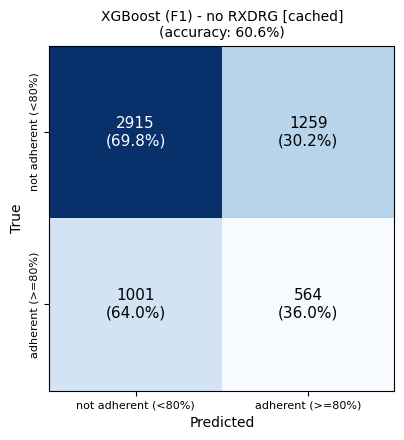

In [14]:
# HalvingGridSearchCV - F1-tuned XGBoost
_CACHE_NAME = "xgb_f1_halving_80pct"
_cached = try_load_model_cache(_CACHE_NAME)


def _xgb_base():
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbosity=0,
        scale_pos_weight=scale_pos_weight,
    )


if _cached is not None:
    display(_cached["metrics"])
    best_xgb = _cached["estimator"]
    if best_xgb is None:
        print("WARN: metrics cached but estimator .joblib missing - set FORCE_REFIT_MODELS=True once.")
    else:
        y_pred_xgb = best_xgb.predict(X_test_xgb)
        y_proba_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]
        record(
            "XGBoost (F1-tuned)", y_test_xgb, y_proba_xgb, y_pred=y_pred_xgb,
            n_features=X_train_xgb.shape[1], note="Step N, cached",
        )
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        plot_cm_with_recall(
            confusion_matrix(y_test_xgb, y_pred_xgb), ax, "XGBoost (F1) - no RXDRG [cached]"
        )
        plt.tight_layout()
        plt.show()
        best_score_xgb = float(_cached["metrics"]["best_cv_score"].iloc[0])
else:
    cv_xgb = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search_xgb = HalvingGridSearchCV(
        estimator=make_pipeline(_xgb_base()),
        param_grid=XGB_PIPE_GRID,
        scoring="f1",
        cv=cv_xgb,
        factor=3,
        resource="n_samples",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    t0 = time.perf_counter()
    search_xgb.fit(X_train_xgb, y_train_xgb)
    print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
    print("Best params:", search_xgb.best_params_)
    print(f"Best CV f1 (adherent class): {search_xgb.best_score_:.4f}")

    best_xgb = search_xgb.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test_xgb)
    y_proba_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]
    row = record(
        "XGBoost (F1-tuned)", y_test_xgb, y_proba_xgb, y_pred=y_pred_xgb,
        n_features=X_train_xgb.shape[1], note="Step N",
    )

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    plot_cm_with_recall(confusion_matrix(y_test_xgb, y_pred_xgb), ax, "XGBoost (F1) - no RXDRG")
    plt.tight_layout()
    plt.show()

    best_score_xgb = float(search_xgb.best_score_)
    save_model_cache(
        _CACHE_NAME,
        pd.DataFrame([{
            "model": _CACHE_NAME,
            "scoring": "f1",
            "resampling": RESAMPLE_LABEL,
            "best_cv_score": best_score_xgb,
            "test_accuracy": row["accuracy"],
            "test_roc_auc": row["roc_auc"],
            "test_recall_adherent": row["recall_adherent"],
            **{f"param_{k}": str(v) for k, v in search_xgb.best_params_.items()},
        }]),
        best_xgb,
    )


[model cache hit] xgb_auc_halving_80pct - skip training (xgb_auc_halving_80pct_metrics.parquet)


,model,scoring,resampling,best_cv_score,test_roc_auc,test_recall_adherent,param_clf__colsample_bytree,param_clf__learning_rate,param_clf__max_depth,param_clf__min_child_weight,param_clf__n_estimators,param_clf__reg_lambda,param_clf__subsample
0,xgb_auc_halving_80pct,roc_auc,SMOTE 0.5 + undersample 1.0,0.583182,0.591216,0.286262,0.8,0.01,7,1,200,1.0,0.8



--- XGBoost (AUC-tuned) ---
                     precision    recall  f1-score   support

not adherent (<80%)      0.748     0.796     0.771      4174
   adherent (>=80%)      0.345     0.286     0.313      1565

           accuracy                          0.657      5739
          macro avg      0.546     0.541     0.542      5739
       weighted avg      0.638     0.657     0.646      5739

accuracy 0.657 | balanced acc 0.541 | ROC-AUC 0.5912 | PR-AUC 0.3300
recall: non-adherent 0.796 | adherent 0.286


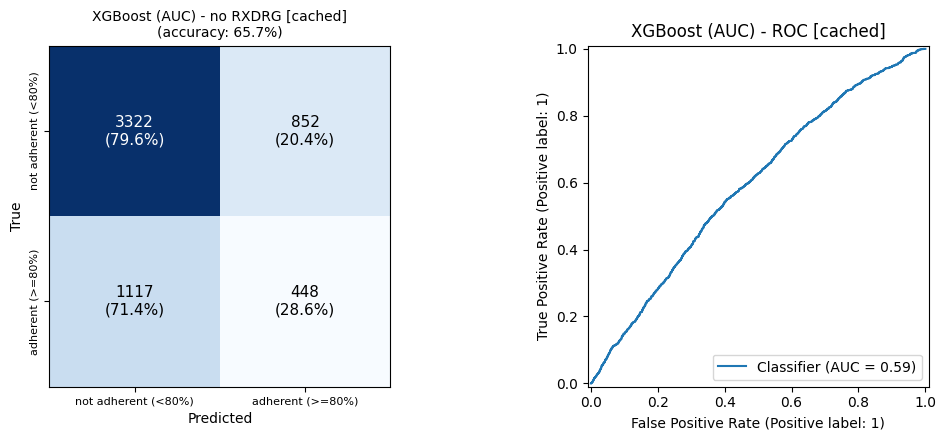

In [15]:
# HalvingGridSearchCV - AUC-tuned XGBoost
_CACHE_NAME = "xgb_auc_halving_80pct"
_cached = try_load_model_cache(_CACHE_NAME)


def _xgb_auc_report(model, tag=""):
    y_pred_a = model.predict(X_test_xgb)
    y_proba_a = model.predict_proba(X_test_xgb)[:, 1]
    row = record(
        "XGBoost (AUC-tuned)", y_test_xgb, y_proba_a, y_pred=y_pred_a,
        n_features=X_train_xgb.shape[1], note=f"Step N{tag}",
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    plot_cm_with_recall(
        confusion_matrix(y_test_xgb, y_pred_a), axes[0], f"XGBoost (AUC) - no RXDRG{tag}"
    )
    RocCurveDisplay.from_predictions(y_test_xgb, y_proba_a, ax=axes[1])
    axes[1].set_title(f"XGBoost (AUC) - ROC{tag}")
    plt.tight_layout()
    plt.show()
    return row


if _cached is not None:
    display(_cached["metrics"])
    best_xgb_auc = _cached["estimator"]
    if best_xgb_auc is None:
        print("WARN: metrics cached but estimator .joblib missing - set FORCE_REFIT_MODELS=True once.")
    else:
        _xgb_auc_report(best_xgb_auc, " [cached]")
        best_score_xgb_auc = float(_cached["metrics"]["best_cv_score"].iloc[0])
else:
    cv_xgb_auc = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search_xgb_auc = HalvingGridSearchCV(
        estimator=make_pipeline(_xgb_base()),
        param_grid=XGB_PIPE_GRID,
        scoring="roc_auc",
        cv=cv_xgb_auc,
        factor=3,
        resource="n_samples",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    t0 = time.perf_counter()
    search_xgb_auc.fit(X_train_xgb, y_train_xgb)
    print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
    print("Best params:", search_xgb_auc.best_params_)
    print(f"Best CV roc_auc: {search_xgb_auc.best_score_:.4f}")

    best_xgb_auc = search_xgb_auc.best_estimator_
    row_a = _xgb_auc_report(best_xgb_auc)
    best_score_xgb_auc = float(search_xgb_auc.best_score_)
    save_model_cache(
        _CACHE_NAME,
        pd.DataFrame([{
            "model": _CACHE_NAME,
            "scoring": "roc_auc",
            "resampling": RESAMPLE_LABEL,
            "best_cv_score": best_score_xgb_auc,
            "test_roc_auc": row_a["roc_auc"],
            "test_recall_adherent": row_a["recall_adherent"],
            **{f"param_{k}": str(v) for k, v in search_xgb_auc.best_params_.items()},
        }]),
        best_xgb_auc,
    )


Gain importance - top 20 (AUC-tuned XGBoost, SMOTE 0.5 + undersample 1.0)
Best params: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'reg_lambda': 1.0}


,gain_importance
REGIONXX,0.144141
RACETHX,0.052717
n_conditions,0.033744
MARRYXX,0.030754
ICD_J45,0.026245
ICD_J30,0.016621
n_drugs,0.016607
ICD_E78,0.016175
ICD_M06,0.016022
ICD_J44,0.015693


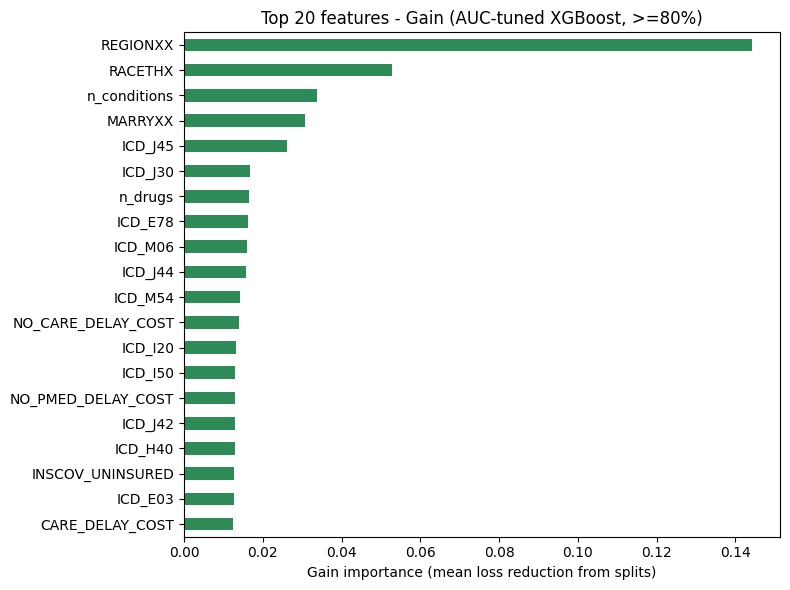

In [16]:
# Gain feature importance - prefers the AUC-tuned booster
_xgb_pipe = best_xgb_auc if "best_xgb_auc" in dir() and best_xgb_auc is not None else best_xgb
_xgb_label = "AUC-tuned" if _xgb_pipe is locals().get("best_xgb_auc") else "F1-tuned"

if _xgb_pipe is None:
    print("Skip Gain importance - cached metrics only. Set FORCE_REFIT_MODELS=True to retrain.")
else:
    TOP_N_XGB = 20
    _booster = _xgb_pipe.named_steps["clf"]
    gain_imp_xgb = (
        pd.Series(_booster.feature_importances_, index=X_train_xgb.columns)
        .sort_values(ascending=False)
    )
    print(f"Gain importance - top {TOP_N_XGB} ({_xgb_label} XGBoost, {RESAMPLE_LABEL})")
    print("Best params:", {k: _booster.get_params()[k] for k in XGB_PARAM_GRID})
    display(gain_imp_xgb.head(TOP_N_XGB).to_frame("gain_importance"))

    fig, ax = plt.subplots(figsize=(8, 6))
    gain_imp_xgb.head(TOP_N_XGB).iloc[::-1].plot(kind="barh", ax=ax, color="seagreen")
    ax.set_xlabel("Gain importance (mean loss reduction from splits)")
    ax.set_title(f"Top {TOP_N_XGB} features - Gain ({_xgb_label} XGBoost, >={ADH_THRESHOLD}%)")
    plt.tight_layout()
    plt.show()


/Users/friana/Medical Adherence/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP mean |value| - top 20 (AUC-tuned XGBoost, n=500)


,mean_abs_shap
REGIONXX,0.108650
AGE,0.057555
RACETHX,0.056886
ICD_E78,0.043217
n_conditions,0.033314
PATIENT_COST_SHARE,0.031569
ICD_J45,0.028571
n_drugs,0.028192
ICD_I10,0.025843
MARRYXX,0.022450


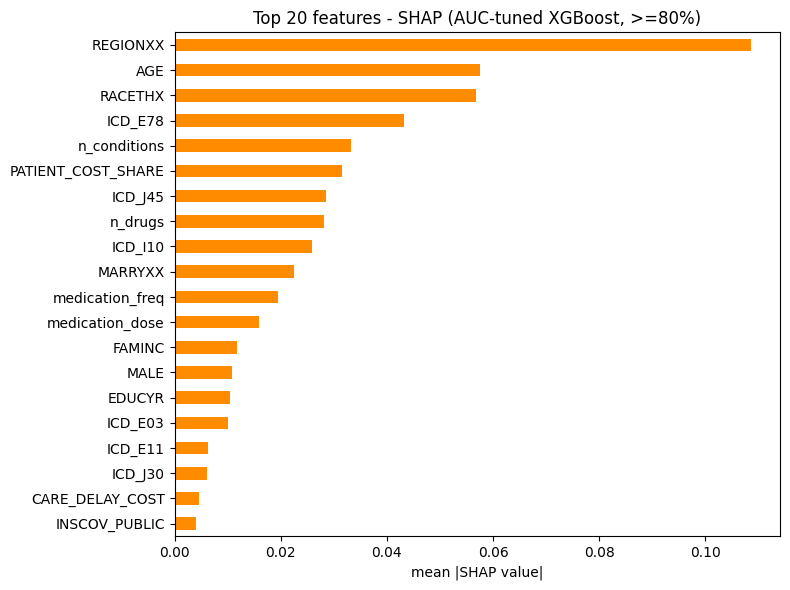

SHAP beeswarm (class = adherent):


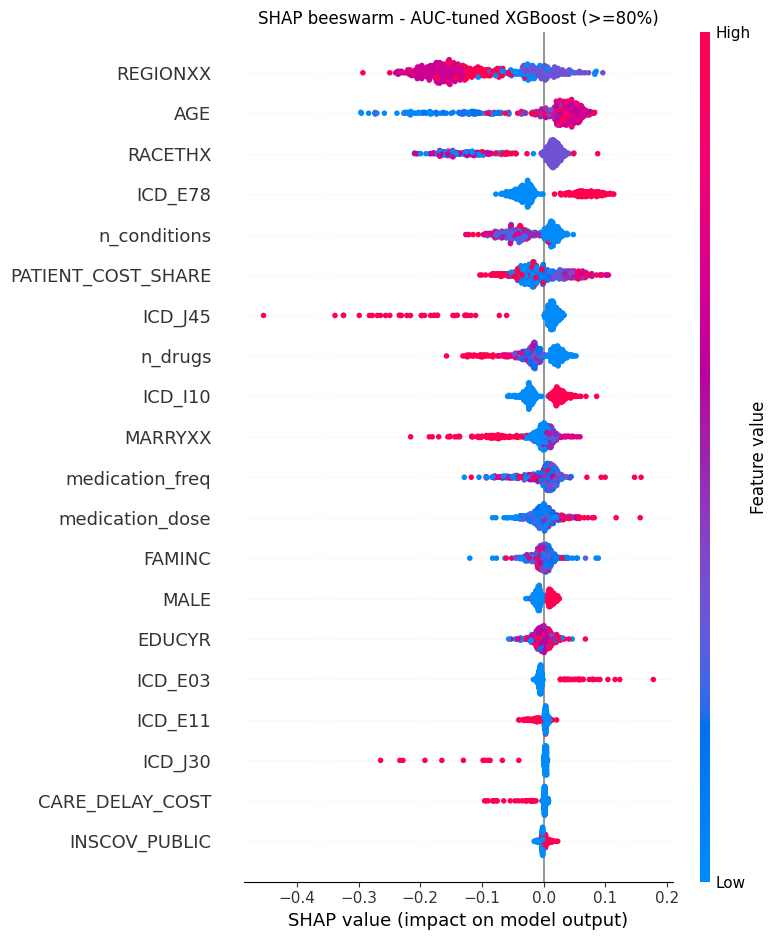

In [17]:
# SHAP on the tuned booster (skips cleanly when shap is missing)
SHAP_SAMPLE_XGB = 500

try:
    import shap
except ImportError:
    print("shap not installed - skipping (pip install shap)")
else:
    if _xgb_pipe is None:
        print("Skip SHAP - no fitted estimator available.")
    else:
        X_shap = X_train_xgb.sample(
            n=min(SHAP_SAMPLE_XGB, len(X_train_xgb)), random_state=RANDOM_STATE
        )
        explainer = shap.TreeExplainer(_xgb_pipe.named_steps["clf"])
        shap_values = explainer.shap_values(X_shap)
        if isinstance(shap_values, list):
            shap_pos = shap_values[1]
        elif getattr(shap_values, "ndim", 0) == 3:
            shap_pos = shap_values[:, :, 1]
        else:
            shap_pos = shap_values

        mean_abs_shap = (
            pd.Series(np.abs(shap_pos).mean(axis=0), index=X_shap.columns)
            .sort_values(ascending=False)
        )
        print(f"SHAP mean |value| - top {TOP_N_XGB} ({_xgb_label} XGBoost, n={len(X_shap)})")
        display(mean_abs_shap.head(TOP_N_XGB).to_frame("mean_abs_shap"))

        fig, ax = plt.subplots(figsize=(8, 6))
        mean_abs_shap.head(TOP_N_XGB).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
        ax.set_xlabel("mean |SHAP value|")
        ax.set_title(f"Top {TOP_N_XGB} features - SHAP ({_xgb_label} XGBoost, >={ADH_THRESHOLD}%)")
        plt.tight_layout()
        plt.show()

        print("SHAP beeswarm (class = adherent):")
        shap.summary_plot(shap_pos, X_shap, max_display=TOP_N_XGB, show=False)
        plt.title(f"SHAP beeswarm - {_xgb_label} XGBoost (>={ADH_THRESHOLD}%)")
        plt.tight_layout()
        plt.show()


In [18]:
# Predict is_adherent with the tuned XGBoost pipeline
if _xgb_pipe is None:
    print("Skip XGB predict demo - cached metrics only.")
else:
    def predict_adherence_xgb(features: pd.DataFrame, model=None, threshold: float = 0.5):
        """Return the predicted label and P(adherent) from the tuned XGBoost pipeline."""
        model = model or _xgb_pipe
        cols = list(X_train_xgb.columns)
        missing = [c for c in cols if c not in features.columns]
        if missing:
            raise KeyError(f"missing feature columns: {missing[:10]}{'...' if len(missing) > 10 else ''}")
        X_new = features[cols].copy()
        if "AGE" in X_new.columns:
            X_new["AGE"] = pd.to_numeric(X_new["AGE"], errors="coerce")
        X_new = X_new.astype(np.float32).fillna(-999.0)
        proba = model.predict_proba(X_new)[:, 1]
        return pd.DataFrame(
            {"is_adherent_pred": (proba >= threshold).astype(int), "p_adherent": proba},
            index=features.index,
        )

    pred_test_xgb = predict_adherence_xgb(X_test_xgb)
    pred_test_xgb["is_adherent_true"] = y_test_xgb.to_numpy()
    display(pred_test_xgb.head(10))
    print(
        "holdout accuracy:",
        round(float((pred_test_xgb["is_adherent_pred"] == pred_test_xgb["is_adherent_true"]).mean()), 4),
    )


,is_adherent_pred,p_adherent,is_adherent_true
7152,0,0.481753,0
7116,1,0.516593,0
7760,0,0.414702,0
15520,0,0.457856,0
8572,1,0.506721,1
11225,0,0.492168,1
8213,0,0.420427,0
22320,0,0.387823,0
8047,0,0.384731,0
9358,0,0.476410,0


holdout accuracy: 0.6569


## 6. Does the resampling actually help?

The concern behind this whole notebook is a model that learns "everyone is non-adherent". This
section fits one fixed XGBoost on the person-split training set five times, changing only how
the imbalance is handled, and compares them on the untouched holdout. No grid search, so it
runs in seconds.

Read the **recall (adherent)** column against **accuracy**. An unbalanced fit wins on accuracy
by conceding the minority class; the useful configurations trade a few points of accuracy for a
large gain in adherent recall. `ROC-AUC` and `PR-AUC` are threshold-free, so they show whether
the ranking improved at all or the decision boundary merely moved. If those two stay flat while
recall swings, resampling is relocating errors rather than adding skill — worth knowing before
reading anything into a recall improvement.

Expect SMOTE-to-parity to underperform here. With 310 of 319 features being sparse 0/1
indicators, interpolated minority rows land in regions of a 319-dimensional space where no real
patient of either class sits, so a tree can satisfy them with a few cheap splits and leave the
contested region untouched. The effect is well documented for high-dimensional data (Blagus &
Lusa, 2013) and it is not an artefact of rounding the dummies — `SMOTENC`, which votes
categorical features properly instead of interpolating them, behaves the same way. Holding SMOTE
to a partial ratio and finishing with undersampling avoids it, which is why `smote_under` is the
default.


[model cache hit] resampling_ablation_80pct - skip training (resampling_ablation_80pct_metrics.parquet)


,strategy,train_rows,train_%_adherent,accuracy,balanced_accuracy,recall_non_adherent,recall_adherent,precision_adherent,f1_adherent,roc_auc,pr_auc,fit_seconds
0,no correction,22960,27.1429,0.7219,0.5000,1.0000,0.0000,0.0000,0.0000,0.5806,0.3294,1.3
1,scale_pos_weight,22960,27.1429,0.5317,0.5561,0.5011,0.6110,0.3206,0.4206,0.5809,0.3334,1.6
2,random undersample,12464,50.0000,0.5252,0.5558,0.4868,0.6248,0.3193,0.4227,0.5798,0.3309,0.9
3,SMOTE to parity,33456,50.0000,0.7208,0.5016,0.9956,0.0075,0.4000,0.0148,0.5793,0.3327,1.9
4,SMOTE 0.5 + undersample,16728,50.0000,0.6229,0.5452,0.7203,0.3701,0.3377,0.3532,0.5812,0.3340,1.6



Fixed XGBoost, person-split holdout (5,731 rows, real class balance):


strategy,train_rows,train_%_adherent,accuracy,balanced_accuracy,recall_non_adherent,recall_adherent,precision_adherent,f1_adherent,roc_auc,pr_auc,fit_seconds
no correction,22960,27.1,0.722,0.500,1.000,0.000,0.000,0.000,0.5806,0.3294,1.300000
scale_pos_weight,22960,27.1,0.532,0.556,0.501,0.611,0.321,0.421,0.5809,0.3334,1.600000
random undersample,12464,50.0,0.525,0.556,0.487,0.625,0.319,0.423,0.5798,0.3309,0.900000
SMOTE to parity,33456,50.0,0.721,0.502,0.996,0.008,0.400,0.015,0.5793,0.3327,1.900000
SMOTE 0.5 + undersample,16728,50.0,0.623,0.545,0.720,0.370,0.338,0.353,0.5812,0.3340,1.600000


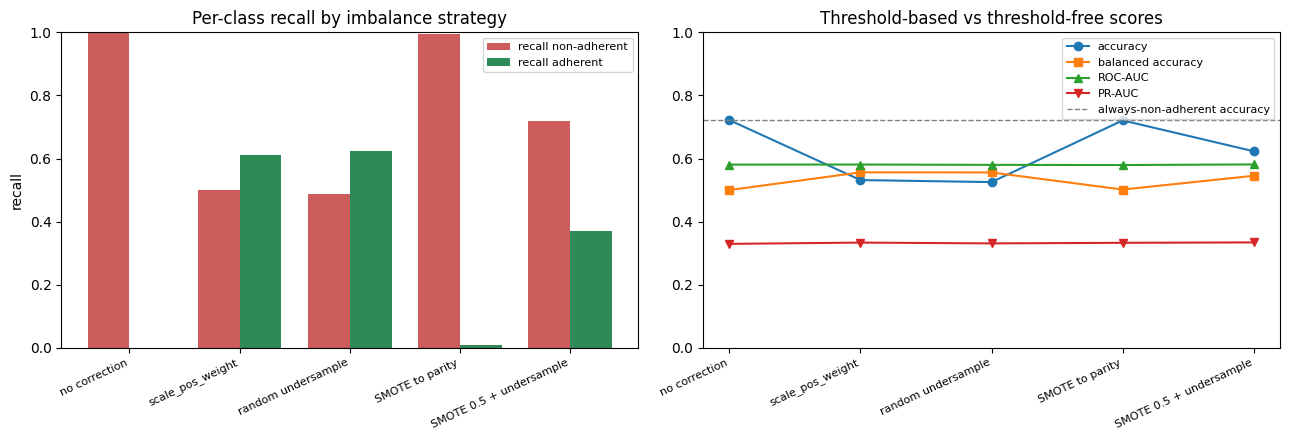

In [19]:
_CACHE_NAME = "resampling_ablation_80pct"
_cached = try_load_model_cache(_CACHE_NAME)

XGB_FIXED = dict(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

_X_tr_ab = X_train.astype(np.float32)
_X_te_ab = X_test.astype(np.float32)
_neg, _pos = np.bincount(y_train.astype(int))

ABLATION_MODES = [
    ("none", "no correction", {}),
    ("none", "scale_pos_weight", {"scale_pos_weight": _neg / _pos}),
    ("under", "random undersample", {}),
    ("smote", "SMOTE to parity", {}),
    ("smote_under", f"SMOTE {SMOTE_RATIO} + undersample", {}),
]

if _cached is not None:
    ablation_resample_df = _cached["metrics"].copy()
    display(ablation_resample_df.round(4))
else:
    rows = []
    for mode, label, extra in ABLATION_MODES:
        t0 = time.perf_counter()
        X_fit, y_fit = resample_now(_X_tr_ab, y_train, mode=mode)
        clf = XGBClassifier(**{**XGB_FIXED, **extra})
        clf.fit(X_fit, y_fit)
        proba = clf.predict_proba(_X_te_ab)[:, 1]
        pred = (proba >= 0.5).astype(int)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, pred, labels=[0, 1], zero_division=0
        )
        rows.append({
            "strategy": label,
            "train_rows": int(len(y_fit)),
            "train_%_adherent": 100 * float(np.asarray(y_fit).mean()),
            "accuracy": float((pred == y_test.to_numpy()).mean()),
            "balanced_accuracy": float(balanced_accuracy_score(y_test, pred)),
            "recall_non_adherent": float(rec[0]),
            "recall_adherent": float(rec[1]),
            "precision_adherent": float(prec[1]),
            "f1_adherent": float(f1[1]),
            "roc_auc": float(roc_auc_score(y_test, proba)),
            "pr_auc": float(average_precision_score(y_test, proba)),
            "fit_seconds": round(time.perf_counter() - t0, 1),
        })
        print(f"  {label:<28} recall_adherent={rec[1]:.3f}  acc={rows[-1]['accuracy']:.3f}")

    ablation_resample_df = pd.DataFrame(rows)
    save_model_cache(_CACHE_NAME, ablation_resample_df, None)

print(f"\nFixed XGBoost, person-split holdout ({len(y_test):,} rows, real class balance):")
display(
    ablation_resample_df.style.format({
        "train_%_adherent": "{:.1f}",
        "accuracy": "{:.3f}",
        "balanced_accuracy": "{:.3f}",
        "recall_non_adherent": "{:.3f}",
        "recall_adherent": "{:.3f}",
        "precision_adherent": "{:.3f}",
        "f1_adherent": "{:.3f}",
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
    }).hide(axis="index").background_gradient(subset=["recall_adherent", "pr_auc"], cmap="Greens")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
_idx = np.arange(len(ablation_resample_df))
_w = 0.38
axes[0].bar(_idx - _w / 2, ablation_resample_df["recall_non_adherent"], _w,
            label="recall non-adherent", color="indianred")
axes[0].bar(_idx + _w / 2, ablation_resample_df["recall_adherent"], _w,
            label="recall adherent", color="seagreen")
axes[0].set_xticks(_idx)
axes[0].set_xticklabels(ablation_resample_df["strategy"], rotation=25, ha="right", fontsize=8)
axes[0].set_ylabel("recall")
axes[0].set_ylim(0, 1)
axes[0].set_title("Per-class recall by imbalance strategy")
axes[0].legend(fontsize=8)

axes[1].plot(_idx, ablation_resample_df["accuracy"], "o-", label="accuracy")
axes[1].plot(_idx, ablation_resample_df["balanced_accuracy"], "s-", label="balanced accuracy")
axes[1].plot(_idx, ablation_resample_df["roc_auc"], "^-", label="ROC-AUC")
axes[1].plot(_idx, ablation_resample_df["pr_auc"], "v-", label="PR-AUC")
axes[1].axhline(1 - y_test.mean(), color="grey", linestyle="--", linewidth=1,
                label="always-non-adherent accuracy")
axes[1].set_xticks(_idx)
axes[1].set_xticklabels(ablation_resample_df["strategy"], rotation=25, ha="right", fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title("Threshold-based vs threshold-free scores")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [20]:
# Read the ablation: did any strategy add ranking skill, or only move the boundary?
_auc_spread = ablation_resample_df["roc_auc"].max() - ablation_resample_df["roc_auc"].min()
_pr_spread = ablation_resample_df["pr_auc"].max() - ablation_resample_df["pr_auc"].min()
_rec_spread = ablation_resample_df["recall_adherent"].max() - ablation_resample_df["recall_adherent"].min()
_best_rec = ablation_resample_df.loc[ablation_resample_df["recall_adherent"].idxmax()]
_best_pr = ablation_resample_df.loc[ablation_resample_df["pr_auc"].idxmax()]

print(f"across {len(ablation_resample_df)} imbalance strategies:")
print(f"  recall (adherent) spans {_rec_spread:.3f}")
print(f"  ROC-AUC spans          {_auc_spread:.4f}  ({ablation_resample_df['roc_auc'].min():.4f} - {ablation_resample_df['roc_auc'].max():.4f})")
print(f"  PR-AUC  spans          {_pr_spread:.4f}  ({ablation_resample_df['pr_auc'].min():.4f} - {ablation_resample_df['pr_auc'].max():.4f})")
print(f"\nhighest adherent recall: {_best_rec['strategy']} ({_best_rec['recall_adherent']:.3f} recall, {_best_rec['accuracy']:.3f} accuracy)")
print(f"highest PR-AUC:          {_best_pr['strategy']} ({_best_pr['pr_auc']:.4f})")

if _auc_spread < 0.02 and _rec_spread > 0.2:
    print(
        "\nReading: ranking quality is flat while recall swings widely, so resampling is moving\n"
        "the decision boundary, not making the features more informative. The ceiling here is\n"
        f"the feature set (ROC-AUC around {ablation_resample_df['roc_auc'].mean():.2f}), not the\n"
        "class balance. Treat the choice of strategy as a policy question about which error you\n"
        "would rather make, and see the threshold sweep below for the same trade-off on one model."
    )
else:
    print("\nReading: strategies differ in ranking quality too, not just in threshold placement.")


across 5 imbalance strategies:
  recall (adherent) spans 0.625
  ROC-AUC spans          0.0019  (0.5793 - 0.5812)
  PR-AUC  spans          0.0046  (0.3294 - 0.3340)

highest adherent recall: random undersample (0.625 recall, 0.525 accuracy)
highest PR-AUC:          SMOTE 0.5 + undersample (0.3340)

Reading: ranking quality is flat while recall swings widely, so resampling is moving
the decision boundary, not making the features more informative. The ceiling here is
the feature set (ROC-AUC around 0.58), not the
class balance. Treat the choice of strategy as a policy question about which error you
would rather make, and see the threshold sweep below for the same trade-off on one model.


fixed XGBoost, SMOTE 0.5 + undersample 1.0, person-split holdout (5,731 rows)
true adherent rate in holdout: 0.278
best F1 on the adherent class: 0.446 at threshold 0.35
  F1 floor from predicting everyone adherent: 0.435
best balanced accuracy: 0.555 at threshold 0.45

F1 on the minority class beats the predict-everyone floor by only +0.011, so its argmax sits at a near-degenerate threshold
(89% of the holdout called adherent). Balanced accuracy is the more honest target for
picking a cutoff here, so 0.45 is what gets recorded below.


threshold,predicted_adherent_rate,accuracy,balanced_accuracy,recall_non_adherent,recall_adherent,precision_adherent,f1_adherent
0.20,0.996,0.281,0.502,0.005,0.998,0.279,0.436
0.25,0.984,0.290,0.506,0.019,0.993,0.281,0.438
0.30,0.952,0.315,0.520,0.059,0.981,0.286,0.443
0.35,0.887,0.355,0.533,0.131,0.935,0.293,0.446
0.40,0.754,0.426,0.549,0.273,0.825,0.304,0.444
0.45,0.547,0.523,0.555,0.484,0.627,0.319,0.422
0.50,0.305,0.623,0.545,0.720,0.370,0.338,0.353
0.55,0.101,0.698,0.526,0.913,0.139,0.382,0.204
0.60,0.012,0.719,0.503,0.990,0.017,0.391,0.032
0.65,0.000,0.722,0.500,1.000,0.000,0.000,0.000


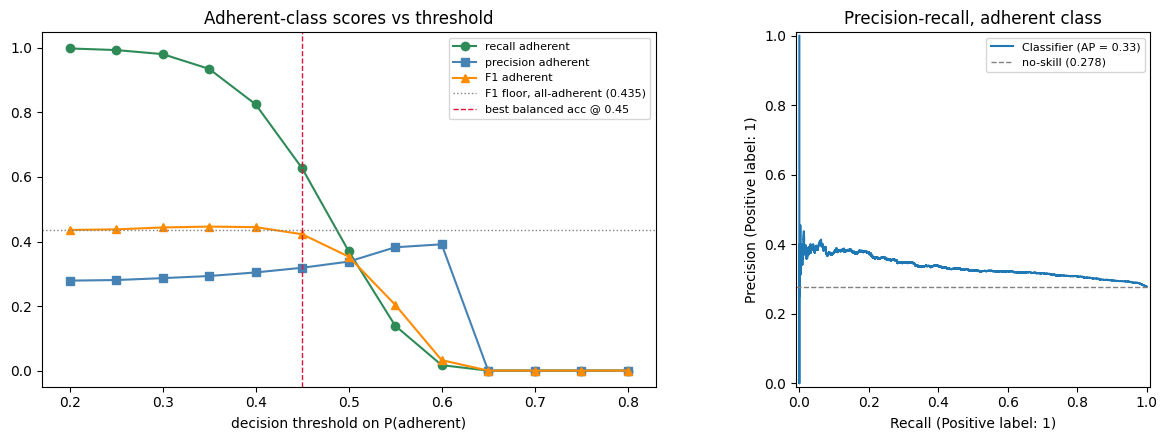

In [21]:
# Same trade-off from a single model: sweep the decision threshold instead of the sampler.
_thr_clf = XGBClassifier(**XGB_FIXED)
_X_fit_thr, _y_fit_thr = resample_now(_X_tr_ab, y_train)
_thr_clf.fit(_X_fit_thr, _y_fit_thr)
_proba_thr = _thr_clf.predict_proba(_X_te_ab)[:, 1]

_grid = np.round(np.arange(0.20, 0.81, 0.05), 2)
_rows = []
for t in _grid:
    pred = (_proba_thr >= t).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, labels=[0, 1], zero_division=0)
    _rows.append({
        "threshold": t,
        "predicted_adherent_rate": float(pred.mean()),
        "accuracy": float((pred == y_test.to_numpy()).mean()),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, pred)),
        "recall_non_adherent": float(rec[0]),
        "recall_adherent": float(rec[1]),
        "precision_adherent": float(prec[1]),
        "f1_adherent": float(f1[1]),
    })

threshold_sweep = pd.DataFrame(_rows)
BEST_F1_THRESHOLD = float(threshold_sweep.loc[threshold_sweep["f1_adherent"].idxmax(), "threshold"])
BEST_BAL_THRESHOLD = float(threshold_sweep.loc[threshold_sweep["balanced_accuracy"].idxmax(), "threshold"])
_best_f1 = float(threshold_sweep["f1_adherent"].max())

# Calling everyone adherent already scores this F1, so it is the floor any threshold must clear.
_prev = float(y_test.mean())
F1_ALL_POSITIVE = 2 * _prev / (1 + _prev)

print(f"fixed XGBoost, {RESAMPLE_LABEL}, person-split holdout ({len(y_test):,} rows)")
print(f"true adherent rate in holdout: {_prev:.3f}")
print(f"best F1 on the adherent class: {_best_f1:.3f} at threshold {BEST_F1_THRESHOLD:.2f}")
print(f"  F1 floor from predicting everyone adherent: {F1_ALL_POSITIVE:.3f}")
print(f"best balanced accuracy: {threshold_sweep['balanced_accuracy'].max():.3f} at threshold {BEST_BAL_THRESHOLD:.2f}")

if _best_f1 - F1_ALL_POSITIVE < 0.02:
    print(
        f"\nF1 on the minority class beats the predict-everyone floor by only "
        f"{_best_f1 - F1_ALL_POSITIVE:+.3f}, so its argmax sits at a near-degenerate threshold\n"
        f"({100 * float(threshold_sweep.loc[threshold_sweep['f1_adherent'].idxmax(), 'predicted_adherent_rate']):.0f}% "
        f"of the holdout called adherent). Balanced accuracy is the more honest target for\n"
        f"picking a cutoff here, so {BEST_BAL_THRESHOLD:.2f} is what gets recorded below."
    )
OPERATING_THRESHOLD = BEST_BAL_THRESHOLD

display(
    threshold_sweep.style.format({
        "threshold": "{:.2f}", "predicted_adherent_rate": "{:.3f}", "accuracy": "{:.3f}",
        "balanced_accuracy": "{:.3f}", "recall_non_adherent": "{:.3f}",
        "recall_adherent": "{:.3f}", "precision_adherent": "{:.3f}", "f1_adherent": "{:.3f}",
    }).hide(axis="index").background_gradient(subset=["f1_adherent"], cmap="Greens")
)

record(
    "XGBoost (fixed, tuned threshold)", y_test, _proba_thr,
    y_pred=(_proba_thr >= OPERATING_THRESHOLD).astype(int),
    n_features=_X_tr_ab.shape[1],
    note=f"Section 6, decision threshold {OPERATING_THRESHOLD:.2f}",
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(threshold_sweep["threshold"], threshold_sweep["recall_adherent"], "o-",
             label="recall adherent", color="seagreen")
axes[0].plot(threshold_sweep["threshold"], threshold_sweep["precision_adherent"], "s-",
             label="precision adherent", color="steelblue")
axes[0].plot(threshold_sweep["threshold"], threshold_sweep["f1_adherent"], "^-",
             label="F1 adherent", color="darkorange")
axes[0].axhline(F1_ALL_POSITIVE, color="grey", linestyle=":", linewidth=1,
                label=f"F1 floor, all-adherent ({F1_ALL_POSITIVE:.3f})")
axes[0].axvline(OPERATING_THRESHOLD, color="crimson", linestyle="--", linewidth=1,
                label=f"best balanced acc @ {OPERATING_THRESHOLD:.2f}")
axes[0].set_xlabel("decision threshold on P(adherent)")
axes[0].set_title("Adherent-class scores vs threshold")
axes[0].legend(fontsize=8)

from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, _proba_thr, ax=axes[1])
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", linewidth=1,
                label=f"no-skill ({y_test.mean():.3f})")
axes[1].set_title("Precision-recall, adherent class")
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()


## 7. Prior-year features (Step P at 80%)

Three lagged features — `prior_is_adherent`, `prior_n_drugs`, `prior_n_cond` — merged on
`DUPERSID` and `YEAR - 1`, then a time split: train on 2021-2022, test on 2023. Both
`is_adherent` and `prior_is_adherent` are now cut at 80%.

The structural counts are unchanged from the 60% run, since the merge geometry does not depend
on the cutoff: **9,919** lagged rows, **8,748** patients, **7,927** train / **1,992** test,
**315** features without priors and **318** with. Only the labels and therefore the AUCs move.
The 60% run's `prior_is_adherent`-alone baseline was **0.6044**; the comparable number at 80%
is printed below.


In [22]:
# Prior-year lag: 3 features, time split, overlap check, AUC ablation - all at 80%
PRIOR_MAP = {
    "is_adherent": "prior_is_adherent",
    "n_drugs": "prior_n_drugs",
    "n_conditions": "prior_n_cond",
}
prior = model_df_all[["DUPERSID", "YEAR", *PRIOR_MAP]].rename(columns=PRIOR_MAP)
prior["YEAR"] += 1

lagged = model_df_all.merge(prior, on=["DUPERSID", "YEAR"], how="inner")
PRIOR_COLS = list(PRIOR_MAP.values())

print(f"after prior-year merge: {len(lagged):,} rows | {lagged['DUPERSID'].nunique():,} patients")
assert len(lagged) == 9919, f"expected 9919 rows, got {len(lagged)}"
assert lagged["DUPERSID"].nunique() == 8748, lagged["DUPERSID"].nunique()

PAPER_ENRICH_COLS = {
    "MARRYXX", "REGIONXX", "EDUCYR", "RACETHX",
    "medication_freq", "medication_dose", "medication_dose_unit",
    "medication_qty_unit", "medication_freq_bin",
}
DROP_FROM_X_P = {"DUPERSID", "YEAR", "is_adherent", "meps_adherence_ratio", *PAPER_ENRICH_COLS}
usable_no_prior = [c for c in lagged.columns if c not in DROP_FROM_X_P and c not in PRIOR_COLS]
usable_with_prior = [c for c in lagged.columns if c not in DROP_FROM_X_P]
assert len(usable_no_prior) == 315, len(usable_no_prior)
assert len(usable_with_prior) == 318, len(usable_with_prior)
print(f"feature counts OK: {len(usable_no_prior)} without prior | {len(usable_with_prior)} with prior")

# prior_is_adherent must equal the YEAR-1 label, not the same-year one.
prev_lookup = model_df_all.set_index(["DUPERSID", "YEAR"])["is_adherent"]
expected_prior = lagged.apply(lambda r: prev_lookup[(r["DUPERSID"], r["YEAR"] - 1)], axis=1)
assert (lagged["prior_is_adherent"].to_numpy() == expected_prior.to_numpy()).all()
print("same-year label leakage check OK (prior_is_adherent == YEAR-1 label at 80%)")

train_p = lagged[lagged["YEAR"].isin([2021, 2022])].copy()
test_p = lagged[lagged["YEAR"] == 2023].copy()
assert len(train_p) == 7927 and len(test_p) == 1992
overlap_p = set(train_p["DUPERSID"]) & set(test_p["DUPERSID"])
assert not overlap_p, f"person leakage: {len(overlap_p)} DUPERSID in both"
print(f"\ntime split: train 2021-2022 {len(train_p):,} | test 2023 {len(test_p):,} | overlap 0")

y_train_p = train_p["is_adherent"].astype(int)
y_test_p = test_p["is_adherent"].astype(int)
describe_balance(y_train_p, "train 2021-2022")
describe_balance(y_test_p, "test 2023")

maj_label = int(test_p["is_adherent"].mode().iloc[0])
MAJORITY_BASELINE_2023 = float((test_p["is_adherent"] == maj_label).mean())
print(
    f"\n2023 majority-class baseline: always predict {maj_label} "
    f"({'non-adherent' if maj_label == 0 else 'adherent'}) -> accuracy "
    f"{100 * MAJORITY_BASELINE_2023:.1f}%"
)


after prior-year merge: 9,919 rows | 8,748 patients
feature counts OK: 315 without prior | 318 with prior
same-year label leakage check OK (prior_is_adherent == YEAR-1 label at 80%)

time split: train 2021-2022 7,927 | test 2023 1,992 | overlap 0
  train 2021-2022              n= 7,927  non-adherent= 5,801 (73.2%)  adherent= 2,126 (26.8%)
  test 2023                    n= 1,992  non-adherent= 1,457 (73.1%)  adherent=   535 (26.9%)

2023 majority-class baseline: always predict 0 (non-adherent) -> accuracy 73.1%


In [23]:
# AUC ablation over the prior-year features, each fit through the resampling pipeline.
_CACHE_NAME = "prior_year_ablation_xgb_80pct"
_cached = try_load_model_cache(_CACHE_NAME)

XGB_FIXED_P = dict(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)


def _auc_xgb(cols):
    """2023 ROC-AUC for a fixed XGBoost on the given columns, resampling train only."""
    Xtr = train_p[cols].astype(np.float32).fillna(-999.0)
    Xte = test_p[cols].astype(np.float32).fillna(-999.0)
    Xfit, yfit = resample_now(Xtr, y_train_p)
    clf = XGBClassifier(**XGB_FIXED_P)
    clf.fit(Xfit, yfit)
    proba = clf.predict_proba(Xte)[:, 1]
    return float(roc_auc_score(y_test_p, proba)), clf, proba


if _cached is not None:
    ablation_df = _cached["metrics"].copy()
    auc_prior1 = float(ablation_df.loc[ablation_df["features"] == "prior_is_adherent alone", "roc_auc_2023"].iloc[0])
    auc_prior3 = float(ablation_df.loc[ablation_df["features"] == "all 3 prior features", "roc_auc_2023"].iloc[0])
else:
    auc_prior1, _, _ = _auc_xgb(["prior_is_adherent"])
    auc_prior3, clf_prior3, proba_prior3 = _auc_xgb(PRIOR_COLS)

    ablation_rows = [
        {"features": "prior_is_adherent alone", "roc_auc_2023": auc_prior1, "delta_vs_prior1": 0.0},
        {"features": "all 3 prior features", "roc_auc_2023": auc_prior3,
         "delta_vs_prior1": auc_prior3 - auc_prior1},
    ]
    for extra in ["prior_n_drugs", "prior_n_cond"]:
        auc_e, _, _ = _auc_xgb(["prior_is_adherent", extra])
        ablation_rows.append({
            "features": f"prior_is_adherent + {extra}",
            "roc_auc_2023": auc_e,
            "delta_vs_prior1": auc_e - auc_prior1,
        })
    for drop in ["prior_n_drugs", "prior_n_cond"]:
        auc_l, _, _ = _auc_xgb([c for c in PRIOR_COLS if c != drop])
        ablation_rows.append({
            "features": f"3 priors without {drop}",
            "roc_auc_2023": auc_l,
            "delta_vs_prior1": auc_l - auc_prior1,
            "drop_from_full3": auc_prior3 - auc_l,
        })

    ablation_df = pd.DataFrame(ablation_rows)
    save_model_cache(_CACHE_NAME, ablation_df, None)

print(f"2023 ROC-AUC | prior_is_adherent alone : {auc_prior1:.4f}   (60% run: 0.6044)")
print(f"2023 ROC-AUC | all 3 prior features    : {auc_prior3:.4f}")
print(f"delta (3 priors - 1 prior): {auc_prior3 - auc_prior1:+.4f}\n")
display(ablation_df.round(4))

best_added = max(
    ["prior_n_drugs", "prior_n_cond"],
    key=lambda c: float(
        ablation_df.loc[ablation_df["features"] == f"prior_is_adherent + {c}", "delta_vs_prior1"].iloc[0]
    ),
)
print(f"most helpful added prior feature: {best_added}")

lagged_df = lagged
prior_auc_1 = auc_prior1
prior_auc_3 = auc_prior3


[model cache hit] prior_year_ablation_xgb_80pct - skip training (prior_year_ablation_xgb_80pct_metrics.parquet)
2023 ROC-AUC | prior_is_adherent alone : 0.6012   (60% run: 0.6044)
2023 ROC-AUC | all 3 prior features    : 0.5854
delta (3 priors - 1 prior): -0.0158



,features,roc_auc_2023,delta_vs_prior1,drop_from_full3
0,prior_is_adherent alone,0.6012,0.0000,NaN
1,all 3 prior features,0.5854,-0.0158,NaN
2,prior_is_adherent + prior_n_drugs,0.5942,-0.0070,NaN
3,prior_is_adherent + prior_n_cond,0.5894,-0.0118,NaN
4,3 priors without prior_n_drugs,0.5894,-0.0118,-0.0040
5,3 priors without prior_n_cond,0.5942,-0.0070,-0.0088


most helpful added prior feature: prior_n_drugs


## 8. Fixed-XGBoost feature-group comparison (Step Q at 80%)

Same lagged panel and 2021-2022 / 2023 split as Section 7, no grid search, fixed
`n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
reg_lambda=5.0`. Feature-group sizes are unchanged (25 / 99 / 315 / 3 / 318); Step R
enrichments stay out until Section 9.


In [24]:
# Fixed XGBoost by feature group, 2023 holdout, resampling on the training half only.
ICD_COLS = [c for c in lagged.columns if c.startswith("ICD_")]
RX_COLS = [c for c in lagged.columns if c.startswith("RXDRG_")]
DEMO_COLS = [
    c for c in lagged.columns
    if c not in DROP_FROM_X_P and c not in PRIOR_COLS
    and not c.startswith(("ICD_", "RXDRG_"))
]
CURRENT_NO_PRIOR = [c for c in lagged.columns if c not in DROP_FROM_X_P and c not in PRIOR_COLS]
EVERYTHING_PRIOR = [c for c in lagged.columns if c not in DROP_FROM_X_P]

assert len(DEMO_COLS) == 25, len(DEMO_COLS)
assert len(DEMO_COLS) + len(ICD_COLS) == 99, (len(DEMO_COLS), len(ICD_COLS))
assert len(CURRENT_NO_PRIOR) == 315, len(CURRENT_NO_PRIOR)
assert len(EVERYTHING_PRIOR) == 318, len(EVERYTHING_PRIOR)

feature_groups = {
    "demographics only": DEMO_COLS,
    "demographics + ICD": DEMO_COLS + ICD_COLS,
    "current recipe (no prior)": CURRENT_NO_PRIOR,
    "prior-year only": PRIOR_COLS,
    "everything + prior": EVERYTHING_PRIOR,
}


def _prep_X(df, cols):
    X = df[cols].copy()
    if "AGE" in X.columns:
        X["AGE"] = pd.to_numeric(X["AGE"], errors="coerce")
    return X.select_dtypes(include=[np.number, "bool"]).astype(np.float32).fillna(-999.0)


_CACHE_NAME = "xgb_feature_groups_80pct"
_cached = try_load_model_cache(_CACHE_NAME)

if _cached is not None:
    xgb_group_results = _cached["metrics"].copy()
    models_by_group = _cached["estimator"] or {}
    print(f"loaded {len(models_by_group)} cached estimators")
else:
    rows = []
    models_by_group = {}
    for name, cols in feature_groups.items():
        cols = list(dict.fromkeys(cols))
        X_tr = _prep_X(train_p, cols)
        X_te = _prep_X(test_p, cols).reindex(columns=X_tr.columns, fill_value=-999.0)
        X_fit, y_fit = resample_now(X_tr, y_train_p)
        clf = XGBClassifier(**XGB_FIXED_P)
        clf.fit(X_fit, y_fit)
        proba = clf.predict_proba(X_te)[:, 1]
        pred = (proba >= 0.5).astype(int)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test_p, pred, labels=[0, 1], zero_division=0
        )
        rows.append({
            "model": name,
            "n_features": int(X_tr.shape[1]),
            "roc_auc_2023": float(roc_auc_score(y_test_p, proba)),
            "pr_auc_2023": float(average_precision_score(y_test_p, proba)),
            "accuracy": float((pred == y_test_p.to_numpy()).mean()),
            "recall_adherent": float(rec[1]),
            "f1_adherent": float(f1[1]),
        })
        models_by_group[name] = clf
        print(f"  {name:<28} n_features={X_tr.shape[1]:<4} ROC-AUC={rows[-1]['roc_auc_2023']:.4f}")

    xgb_group_results = pd.DataFrame(rows)
    save_model_cache(_CACHE_NAME, xgb_group_results, models_by_group)

print(f"\n2023 holdout ({len(y_test_p):,} rows, {RESAMPLE_LABEL}):")
display(
    xgb_group_results.style.format({
        "roc_auc_2023": "{:.4f}", "pr_auc_2023": "{:.4f}",
        "accuracy": "{:.3f}", "recall_adherent": "{:.3f}", "f1_adherent": "{:.3f}",
    }).hide(axis="index")
)
print(
    f"majority-class accuracy to beat: {100 * MAJORITY_BASELINE_2023:.1f}% | "
    f"prior-only AUC at 60% was 0.6044"
)


[model cache hit] xgb_feature_groups_80pct - skip training (xgb_feature_groups_80pct_metrics.parquet)
loaded 5 cached estimators

2023 holdout (1,992 rows, SMOTE 0.5 + undersample 1.0):


model,n_features,roc_auc_2023,pr_auc_2023,accuracy,recall_adherent,f1_adherent
demographics only,25,0.5456,0.2952,0.640,0.288,0.300
demographics + ICD,99,0.5616,0.3025,0.618,0.359,0.336
current recipe (no prior),315,0.5751,0.3111,0.623,0.357,0.337
prior-year only,3,0.5854,0.3445,0.662,0.458,0.421
everything + prior,318,0.6323,0.3860,0.670,0.421,0.406


majority-class accuracy to beat: 73.1% | prior-only AUC at 60% was 0.6044


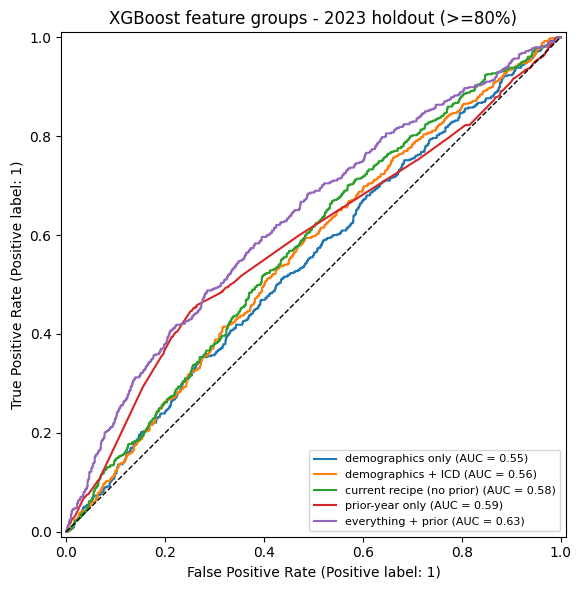

In [25]:
# ROC curves for every feature group on the 2023 holdout
if not models_by_group:
    print("Skip ROC - cached metrics only. Set FORCE_REFIT_MODELS=True to retrain.")
else:
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, clf in models_by_group.items():
        cols = list(dict.fromkeys(feature_groups[name]))
        X_tr = _prep_X(train_p, cols)
        X_te = _prep_X(test_p, cols).reindex(columns=X_tr.columns, fill_value=-999.0)
        proba = clf.predict_proba(X_te)[:, 1]
        RocCurveDisplay.from_predictions(y_test_p, proba, ax=ax, name=name)
        if name == "everything + prior":
            record(
                "XGBoost (everything + prior)", y_test_p, proba,
                n_features=X_tr.shape[1], note="Step Q, 2023 holdout",
                verbose=False,
            )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(f"XGBoost feature groups - 2023 holdout (>={ADH_THRESHOLD}%)")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.show()


## 9. Paper-enriched XGBoost (Step R at 80%)

Adds the Step R columns — `MARRYXX`, `REGIONXX`, `EDUCYR`, `RACETHX` and the `medication_*`
features — on top of everything-plus-prior. Categoricals are one-hot encoded with
`dummy_na=True`; the free-text unit columns stay out, as in the 60% run. Same fixed parameters
and 2021-2022 / 2023 split.


enrichment columns present: 9 of 9
[model cache hit] xgb_paper_enriched_prior_80pct - skip training (xgb_paper_enriched_prior_80pct_metrics.parquet)


,model,resampling,n_features,n_train,n_test,test_roc_auc,test_pr_auc,test_recall_adherent
0,xgb_paper_enriched_prior_80pct,SMOTE 0.5 + undersample 1.0,344,7927,1992,0.637041,0.381747,0.441121



--- XGBoost (paper-enriched + prior) ---
                     precision    recall  f1-score   support

not adherent (<80%)      0.785     0.747     0.766      1457
   adherent (>=80%)      0.391     0.441     0.414       535

           accuracy                          0.665      1992
          macro avg      0.588     0.594     0.590      1992
       weighted avg      0.679     0.665     0.671      1992

accuracy 0.665 | balanced acc 0.594 | ROC-AUC 0.6370 | PR-AUC 0.3817
recall: non-adherent 0.747 | adherent 0.441

n_features=344 | n_train=7,927 | n_test=1,992


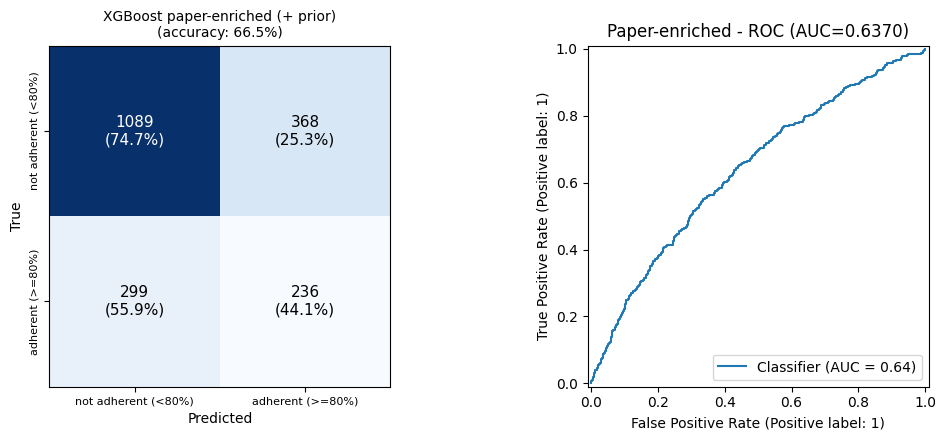

In [26]:
# Paper-enriched XGBoost: everything + prior + Step R enrichments
_ENRICH_PRESENT = [c for c in PAPER_ENRICH_COLS if c in model_df_all.columns]
if not _ENRICH_PRESENT:
    raise RuntimeError("Step R enrichment columns missing from the panel parquet.")
print(f"enrichment columns present: {len(_ENRICH_PRESENT)} of {len(PAPER_ENRICH_COLS)}")

DROP_FROM_X_R = {"DUPERSID", "YEAR", "is_adherent", "meps_adherence_ratio"}
DROP_UNITS_R = {"medication_dose_unit", "medication_qty_unit"}
CAT_ONEHOT_R = ["MARRYXX", "REGIONXX", "RACETHX", "medication_freq_bin"]

feature_cols_r = [c for c in lagged.columns if c not in DROP_FROM_X_R and c not in DROP_UNITS_R]


def _prep_X_paper(df, cols):
    X = df[cols].copy()
    if "AGE" in X.columns:
        X["AGE"] = pd.to_numeric(X["AGE"], errors="coerce")
    for c in CAT_ONEHOT_R:
        if c in X.columns:
            X = pd.get_dummies(X, columns=[c], prefix=c, dummy_na=True)
    X = X.select_dtypes(include=[np.number, "bool"]).astype(np.float32).fillna(-999.0)
    # XGBoost rejects feature names containing [, ] or <
    X.columns = (
        X.columns.astype(str)
        .str.replace("<", "lt_", regex=False)
        .str.replace(">", "gt_", regex=False)
        .str.replace("[", "(", regex=False)
        .str.replace("]", ")", regex=False)
    )
    return X


X_train_r = _prep_X_paper(train_p, feature_cols_r)
X_test_r = _prep_X_paper(test_p, feature_cols_r).reindex(columns=X_train_r.columns, fill_value=-999.0)

_CACHE_NAME = "xgb_paper_enriched_prior_80pct"
_cached = try_load_model_cache(_CACHE_NAME)

if _cached is not None:
    display(_cached["metrics"])
    best_xgb_paper = _cached["estimator"]
else:
    X_fit_r, y_fit_r = resample_now(X_train_r, y_train_p)
    describe_balance(y_train_p, "train (raw)")
    describe_balance(y_fit_r, "train (resampled)")
    best_xgb_paper = XGBClassifier(**XGB_FIXED_P)
    best_xgb_paper.fit(X_fit_r, y_fit_r)

if best_xgb_paper is None:
    print("WARN: metrics cached but estimator missing - set FORCE_REFIT_MODELS=True once.")
else:
    proba_paper = best_xgb_paper.predict_proba(X_test_r)[:, 1]
    row_paper = record(
        "XGBoost (paper-enriched + prior)", y_test_p, proba_paper,
        n_features=X_train_r.shape[1], note="Step R, 2023 holdout",
    )
    print(
        f"\nn_features={X_train_r.shape[1]} | n_train={len(train_p):,} | n_test={len(test_p):,}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    plot_cm_with_recall(
        confusion_matrix(y_test_p, (proba_paper >= 0.5).astype(int)),
        axes[0], "XGBoost paper-enriched (+ prior)",
    )
    RocCurveDisplay.from_predictions(y_test_p, proba_paper, ax=axes[1])
    axes[1].set_title(f"Paper-enriched - ROC (AUC={row_paper['roc_auc']:.4f})")
    plt.tight_layout()
    plt.show()

    if _cached is None:
        save_model_cache(
            _CACHE_NAME,
            pd.DataFrame([{
                "model": _CACHE_NAME,
                "resampling": RESAMPLE_LABEL,
                "n_features": int(X_train_r.shape[1]),
                "n_train": int(len(train_p)),
                "n_test": int(len(test_p)),
                "test_roc_auc": row_paper["roc_auc"],
                "test_pr_auc": row_paper["pr_auc"],
                "test_recall_adherent": row_paper["recall_adherent"],
            }]),
            best_xgb_paper,
        )


## 10. Summary

Every model scored on its own holdout, at the 80% threshold, with the resampling strategy from
Section 2. Sections 4 and 5 use the full four-year panel; Sections 8 and 9 use the 2023 holdout
of the lagged panel, so their rows are not directly comparable to each other — compare within a
split, not across.


In [27]:
summary_df = pd.DataFrame(SUMMARY_ROWS)
if summary_df.empty:
    print("No models scored in this session - all sections loaded from cache without estimators.")
else:
    display(
        summary_df.style.format({
            "roc_auc": "{:.4f}", "pr_auc": "{:.4f}", "accuracy": "{:.3f}",
            "balanced_accuracy": "{:.3f}", "recall_non_adherent": "{:.3f}",
            "recall_adherent": "{:.3f}", "precision_adherent": "{:.3f}",
            "f1_adherent": "{:.3f}",
        }).hide(axis="index").background_gradient(
            subset=["roc_auc", "pr_auc", "recall_adherent"], cmap="Greens"
        )
    )

    out_csv = TABLES_ALL / f"model_summary_{ADH_THRESHOLD}pct.csv"
    summary_df.to_csv(out_csv, index=False)
    print(f"\nwrote {out_csv}")

print(
    f"\nClass balance this notebook was built around: {n_non_80:,} non-adherent vs "
    f"{n_adh_80:,} adherent person-years ({IMBALANCE_RATIO:.2f} : 1)."
)
print(f"Resampling: {RESAMPLE_LABEL}. Caches: {MODELS_CACHE_DIR}")


model,threshold,resampling,n_features,n_test,roc_auc,pr_auc,accuracy,balanced_accuracy,recall_non_adherent,recall_adherent,precision_adherent,f1_adherent,note
RF (F1-tuned),80,SMOTE 0.5 + undersample 1.0,319,5731,0.5723,0.3264,0.530,0.543,0.514,0.573,0.312,0.404,"Step M, cached"
RF (AUC-tuned),80,SMOTE 0.5 + undersample 1.0,319,5731,0.5799,0.3329,0.562,0.552,0.575,0.529,0.324,0.402,Step M [cached]
XGBoost (F1-tuned),80,SMOTE 0.5 + undersample 1.0,105,5739,0.5582,0.3131,0.606,0.529,0.698,0.360,0.309,0.333,"Step N, cached"
XGBoost (AUC-tuned),80,SMOTE 0.5 + undersample 1.0,105,5739,0.5912,0.3300,0.657,0.541,0.796,0.286,0.345,0.313,Step N [cached]
"XGBoost (fixed, tuned threshold)",80,SMOTE 0.5 + undersample 1.0,319,5731,0.5812,0.3340,0.523,0.555,0.484,0.627,0.319,0.422,"Section 6, decision threshold 0.45"
XGBoost (everything + prior),80,SMOTE 0.5 + undersample 1.0,318,1992,0.6323,0.3860,0.670,0.591,0.761,0.421,0.393,0.406,"Step Q, 2023 holdout"
XGBoost (paper-enriched + prior),80,SMOTE 0.5 + undersample 1.0,344,1992,0.6370,0.3817,0.665,0.594,0.747,0.441,0.391,0.414,"Step R, 2023 holdout"



wrote /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_summary_80pct.csv

Class balance this notebook was built around: 20,865 non-adherent vs 7,826 adherent person-years (2.67 : 1).
Resampling: SMOTE 0.5 + undersample 1.0. Caches: /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_cache_80pct
